# Bell states and the CHSH inequality — from entanglement to a measured violation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 8 — Quantum information protocols*

## 1. Introduction and motivation

In 1935 Einstein, Podolsky and Rosen argued that quantum mechanics cannot be a complete description of reality. Their reasoning
used a two-particle state in which measuring one particle instantly tells you the outcome of a measurement on the other, however far
away it is. Either the distant particle "already had" the value — in which case quantum mechanics, which does not list that value,
is incomplete — or measuring one particle somehow acts on the other, which Einstein later called "spooky action at a distance".
For nearly thirty years the debate was philosophical.

In 1964 John Bell turned the philosophy into an **experimentally testable inequality**. If the
outcomes are fixed in advance by some hidden variable $\lambda$ carried by the particles, and if what happens at Alice's detector
does not depend on the knob setting at Bob's, then a certain combination of measured correlations is bounded by a number.
Quantum mechanics predicts a *larger* number. There is no interpretation involved: you build the apparatus, you count clicks, and
nature tells you which side is right. The form of the inequality used in every real experiment since is the one written down by
Clauser, Horne, Shimony and Holt in 1969:

$$S=E(a,b)+E(a,b')+E(a',b)-E(a',b') ,\qquad \vert S\vert\le 2 \quad\text{(local hidden variables)}.$$

Quantum mechanics allows $\vert S\vert$ up to $2\sqrt2\approx2.828$ (Tsirelson's bound) and not one bit more. Experiments — Aspect
and co-workers in the early 1980s, and the loophole-free experiments of 2015 — measure a violation. The 2022 Nobel Prize in Physics
went to Aspect, Clauser and Zeilinger for this line of work. Today the same inequality is a *tool*: a CHSH violation certifies that a
device really produces entanglement, and it is the security foundation of device-independent quantum key distribution.

**What we will do.** Everything, from the state to the measured number and its error bar.

1. **The states.** Define the four Bell states, build them with one Hadamard and one CNOT while tracking the amplitudes gate by
   gate, and measure their correlations $\langle ZZ\rangle,\langle XX\rangle,\langle YY\rangle$ and their maximally mixed
   one-qubit marginals (Sections 3–4).
2. **The classical bound.** Write down what a local hidden-variable model is, prove $\vert S\vert\le2$ in three lines, and check the
   proof by brute force over all deterministic strategies (Section 5).
3. **The quantum prediction.** Derive $E(a,b)=\cos(\theta_a-\theta_b)$ for $\vert\Phi^+\rangle$ from the correlators of Section 4,
   prove Tsirelson's bound from the operator identity $S^2=4-[A,A']\otimes[B,B']$, and find the optimal angles geometrically
   (Sections 6–8).
4. **The experiment.** Simulate it honestly: rotate into the measurement basis, draw single shots from the Born rule with explicit
   PRNG keys, `vmap` over the four settings and over shots, and watch $\hat S$ converge to $2\sqrt2$ with a $1/\sqrt{n}$ error bar.
   Compute how many shots are needed to exceed the classical bound by five standard errors — and check that number by Monte Carlo
   (Sections 9–10).
5. **Noise and loopholes.** Werner states, depolarising and dephasing noise, and the difference between the **entanglement**
   threshold and the **nonlocality** threshold: there are states that are provably entangled and provably local. Then the detection
   loophole: we measure how far the detection efficiency can fall before a maximally entangled pair stops violating CHSH at all
   (Sections 11–13).

### What you will learn

*Physics*

* what a local hidden-variable model is, and exactly which assumption quantum mechanics violates;
* why the four Bell states form a basis, why their marginals are maximally mixed, and how that "randomness" carries the correlation;
* Tsirelson's bound as a statement about non-commuting observables, not about probability;
* that entanglement and Bell nonlocality are *different* resources: the Werner thresholds $1/3$ and $1/\sqrt2$;
* why the critical visibility for the CHSH violation depends on whether you re-optimise the measurement angles.

*Numerical methods*

* estimating a correlator from finite samples: variance $1-E^2$, standard error $1/\sqrt{n}$, error propagation into $S$;
* sample-size planning: how many shots for a $5\sigma$ result, and why "expected $5\sigma$" is not "$5\sigma$ every time";
* maximising a bilinear form over unit vectors (the Horodecki criterion) instead of running a blind four-parameter search.

*Implementation practice*

* measuring a rotated observable as `rotate -> measure Z` with `apply_gate`, on state vectors and on density tensors;
* `jax.vmap` over measurement settings, over shots and over whole repeated experiments; explicit `jax.random` key splitting;
* no Python `if` on random data: detector losses and outcome assignment via `jnp.where`;
* a validation ladder — exact correlator vs sampled correlator, operator identity, analytic error bars vs measured scatter.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation as executable code;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb): reduced density
  matrices, entanglement entropy;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, Kraus channels, negativity;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, basis rotations, sampling bit strings;
* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): Hadamard, CNOT, rotations.

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; a measurement result $s_q\in\{0,1\}$
means the eigenvalue $(-1)^{s_q}$; qubit 0 is the most significant bit of the flat index. Alice always holds qubit 0, Bob qubit 1.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We need very little: the gates $H$, CNOT and $R_y$, the einsum that applies them (`apply_gate` for state vectors, `apply_gate_dm`
for density tensors), reduced density matrices, Pauli expectation values, the Kraus channels, and the negativity. Everything
specific to CHSH is built from scratch below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits` of a density TENSOR.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)"""
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
import itertools

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

BASIS_KETS = ["00", "01", "10", "11"]          # flat index 2*s0 + s1, qubit 0 = most significant bit


def amplitude_table(psi, label):
    """Print the four amplitudes of a 2-qubit state tensor as a small table (real and imaginary part)."""
    v = np.asarray(psi).reshape(-1)
    print(f"  {label}")
    for k, ket in enumerate(BASIS_KETS):
        print(f"     |{ket}> : {v[k].real:+.4f} {v[k].imag:+.4f}i")


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))

## 3. The four Bell states and the circuit that makes them

### 3.1 Definition

Two qubits live in a four-dimensional Hilbert space. The **computational basis** is
$\{\vert00\rangle,\vert01\rangle,\vert10\rangle,\vert11\rangle\}$; every state in it is a *product* state, Alice's qubit and Bob's
qubit each have a definite value. The **Bell basis** is a different orthonormal basis of the same space:

$$\begin{aligned}
\vert\Phi^{+}\rangle&=\tfrac{1}{\sqrt2}\left(\vert00\rangle+\vert11\rangle\right), &
\vert\Phi^{-}\rangle&=\tfrac{1}{\sqrt2}\left(\vert00\rangle-\vert11\rangle\right), \\
\vert\Psi^{+}\rangle&=\tfrac{1}{\sqrt2}\left(\vert01\rangle+\vert10\rangle\right), &
\vert\Psi^{-}\rangle&=\tfrac{1}{\sqrt2}\left(\vert01\rangle-\vert10\rangle\right).
\end{aligned}$$

Orthonormality is immediate: each state is a normalised sum of two basis kets, and any two of them either use disjoint basis kets
($\Phi$ versus $\Psi$) or differ by a sign ($+$ versus $-$), which makes the overlap $\tfrac12-\tfrac12=0$. Four orthonormal
vectors in a four-dimensional space form a basis, so **any** two-qubit state can be expanded in the Bell basis. We will use that
fact constantly, here and in the teleportation notebook.

All four are **maximally entangled**: we prove below that tracing out either qubit leaves the maximally mixed state $\mathbb 1/2$.
$\vert\Psi^-\rangle$ is the famous **singlet**, the only one that is invariant (up to a phase) under $U\otimes U$ for every
single-qubit unitary $U$.

### 3.2 The preparation circuit

One Hadamard and one CNOT are enough. Start from a computational basis state $\vert b_0 b_1\rangle$ and apply

$$\text{CNOT}_{0\to1}\;\left(H_0\otimes\mathbb 1_1\right)\;\vert b_0b_1\rangle .$$

Follow the algebra for $b_0=b_1=0$. The Hadamard acts on qubit 0 only, $H\vert0\rangle=(\vert0\rangle+\vert1\rangle)/\sqrt2$, so

$$\vert00\rangle\;\xrightarrow{\;H_0\;}\;\frac{\vert00\rangle+\vert10\rangle}{\sqrt2}\;\xrightarrow{\;\text{CNOT}_{0\to1}\;}\;
  \frac{\vert00\rangle+\vert11\rangle}{\sqrt2}=\vert\Phi^{+}\rangle ,$$

because CNOT flips qubit 1 exactly when qubit 0 is $\vert1\rangle$. The intermediate state is still a *product*,
$\left(\tfrac{1}{\sqrt2}(\vert0\rangle+\vert1\rangle)\right)\otimes\vert0\rangle$ — the entanglement is created by the CNOT, not by
the Hadamard. Repeating the same two lines for the other three inputs gives

| input | output |
|---|---|
| $\vert00\rangle$ | $\vert\Phi^{+}\rangle$ |
| $\vert01\rangle$ | $\vert\Psi^{+}\rangle$ |
| $\vert10\rangle$ | $\vert\Phi^{-}\rangle$ |
| $\vert11\rangle$ | $\vert\Psi^{-}\rangle$ |

so the circuit is a **unitary map from the computational basis onto the Bell basis**. Run backwards
($H_0$ after $\text{CNOT}_{0\to1}$) it is a *Bell measurement*: it rotates the Bell basis onto the computational basis, where an
ordinary detector can read it out. That is exactly how teleportation works.

### 3.3 Code

In tensor language a two-qubit state is an array of shape $(2,2)$; `apply_gate(psi, H, [0])` is the einsum `"Aa,ab->Ab"` and
`apply_gate(psi, CNOT, [0,1])` is `"ABab,ab->AB"` with the $4\times4$ CNOT matrix reshaped to $(2,2,2,2)$. No $4\times4$ state
vector is ever formed by hand.

In [4]:
# ==============================================================================
# STEP 1: the Bell-state preparation circuit, with gate-by-gate state tracking
# ==============================================================================
BELL_NAMES = ["Phi+", "Psi+", "Phi-", "Psi-"]         # ordered by the input bits (b0,b1) = 00, 01, 10, 11
BELL_KEYS = ["phi+", "psi+", "phi-", "psi-"]          # the engine's `bell_state` labels, same order


def bell_circuit(b0, b1):
    """Prepare a Bell state from the computational basis state |b0 b1>.

    MATH   |B(b0,b1)> = CNOT_{0->1} (H_0 (x) 1) |b0 b1> ;  the four inputs give the four Bell states.
    JAX    b0, b1 are static Python ints (they choose the initial tensor entry); the gates are traced arrays.
    """
    psi = basis_state([b0, b1])
    psi = apply_gate(psi, H, [0])                      # superpose qubit 0
    return apply_gate(psi, CNOT, [0, 1])               # entangle: qubit 1 copies qubit 0 in the Z basis


# --- gate-by-gate walk through the |00> -> |Phi+> case -------------------------------------------------
print("GATE-BY-GATE PREPARATION OF |Phi+>")
psi = basis_state([0, 0])
amplitude_table(psi, "step 0: |00>                       (product, both qubits definite)")
psi = apply_gate(psi, H, [0])
amplitude_table(psi, "step 1: H on qubit 0               (product, qubit 0 in a superposition)")
print(f"     entanglement entropy of the cut 0|1 : {float(entanglement_entropy(psi, [0])):.6f} bit")
psi = apply_gate(psi, CNOT, [0, 1])
amplitude_table(psi, "step 2: CNOT(0 -> 1)               (entangled: |Phi+>)")
print(f"     entanglement entropy of the cut 0|1 : {float(entanglement_entropy(psi, [0])):.6f} bit")

# --- CHECKPOINT: the circuit reproduces the engine's four Bell states ----------------------------------
print("\nCHECKPOINT  circuit output vs the engine's `bell_state`")
for (b0, b1), name, key in zip([(0, 0), (0, 1), (1, 0), (1, 1)], BELL_NAMES, BELL_KEYS):
    err = max_abs(bell_circuit(b0, b1) - bell_state(key))
    print(f"  |{b0}{b1}>  ->  |{name:4s}>   max|difference| = {err:.2e}")
    assert err < TOL

GATE-BY-GATE PREPARATION OF |Phi+>
  step 0: |00>                       (product, both qubits definite)
     |00> : +1.0000 +0.0000i
     |01> : +0.0000 +0.0000i
     |10> : +0.0000 +0.0000i
     |11> : +0.0000 +0.0000i


  step 1: H on qubit 0               (product, qubit 0 in a superposition)
     |00> : +0.7071 +0.0000i
     |01> : +0.0000 +0.0000i
     |10> : +0.7071 +0.0000i
     |11> : +0.0000 +0.0000i


     entanglement entropy of the cut 0|1 : 0.000000 bit
  step 2: CNOT(0 -> 1)               (entangled: |Phi+>)
     |00> : +0.7071 +0.0000i
     |01> : +0.0000 +0.0000i
     |10> : +0.0000 +0.0000i
     |11> : +0.7071 +0.0000i
     entanglement entropy of the cut 0|1 : 1.000000 bit

CHECKPOINT  circuit output vs the engine's `bell_state`
  |00>  ->  |Phi+>   max|difference| = 0.00e+00
  |01>  ->  |Psi+>   max|difference| = 0.00e+00
  |10>  ->  |Phi->   max|difference| = 0.00e+00
  |11>  ->  |Psi->   max|difference| = 0.00e+00


The first Hadamard leaves the state a product — the entanglement entropy of the cut is exactly $0$ — and the CNOT raises it to
exactly $1$ bit, the maximum for one qubit. Reading the amplitude tables: after step 1 the state has weight on
$\vert00\rangle$ and $\vert10\rangle$ (qubit 1 is still $\vert0\rangle$, whatever qubit 0 does), and the CNOT moves the second
amplitude from $\vert10\rangle$ to $\vert11\rangle$. The four preparations match the engine's Bell states to machine precision.

## 4. Correlations and marginals: what makes a Bell state special

### 4.1 The correlators

For a two-qubit state the object that matters for everything below is the $3\times3$ **correlation matrix**

$$T_{ij}=\langle\sigma_i\otimes\sigma_j\rangle=\mathrm{Tr}\!\left[\rho\;\sigma_i\otimes\sigma_j\right],\qquad i,j\in\{x,y,z\},$$

together with the two local Bloch vectors $a_i=\langle\sigma_i\otimes\mathbb 1\rangle$, $b_j=\langle\mathbb 1\otimes\sigma_j\rangle$.
Together with the identity these $3+3+9=15$ numbers are exactly the parameters of a two-qubit density matrix.

Compute $T$ for $\vert\Phi^+\rangle$ by hand. Using $Z\vert0\rangle=\vert0\rangle$, $Z\vert1\rangle=-\vert1\rangle$:

$$Z\otimes Z\;\vert\Phi^+\rangle=\tfrac{1}{\sqrt2}\left((+1)(+1)\vert00\rangle+(-1)(-1)\vert11\rangle\right)=\vert\Phi^+\rangle
  \;\Rightarrow\;\langle ZZ\rangle=+1 .$$

With $X\vert0\rangle=\vert1\rangle$, $X\vert1\rangle=\vert0\rangle$ we get $X\otimes X\vert\Phi^+\rangle=
\tfrac{1}{\sqrt2}(\vert11\rangle+\vert00\rangle)=\vert\Phi^+\rangle$, so $\langle XX\rangle=+1$ as well; and with
$Y\vert0\rangle=i\vert1\rangle$, $Y\vert1\rangle=-i\vert0\rangle$, $Y\otimes Y\vert\Phi^+\rangle=
\tfrac{1}{\sqrt2}(i\cdot i\,\vert11\rangle+(-i)(-i)\vert00\rangle)=-\vert\Phi^+\rangle$, so $\langle YY\rangle=-1$.
Every off-diagonal entry vanishes, e.g. $Z\otimes X\vert\Phi^+\rangle=\tfrac{1}{\sqrt2}(\vert01\rangle-\vert10\rangle)$, which is
orthogonal to $\vert\Phi^+\rangle$. So

$$T\left(\Phi^{+}\right)=\mathrm{diag}(+1,-1,+1) .$$

**This is the whole mystery in one line.** $\langle ZZ\rangle=+1$ says: measure both qubits along $z$ and the results always agree.
$\langle XX\rangle=+1$ says: measure both along $x$ and the results *also* always agree. A classical object carrying instructions
would have to carry a definite $z$-value *and* a definite $x$-value for each particle — and section 5 shows that no such list of
instructions can reproduce the intermediate angles.

### 4.2 The marginals

The reduced state of qubit 0 is obtained by tracing out qubit 1:

$$\rho_0=\mathrm{Tr}_1\vert\Phi^+\rangle\langle\Phi^+\vert
  =\tfrac12\left(\vert0\rangle\langle0\vert+\vert1\rangle\langle1\vert\right)=\frac{\mathbb 1}{2},$$

because the cross terms $\vert0\rangle\langle1\vert\,\mathrm{Tr}\!\left(\vert0\rangle\langle1\vert\right)$ vanish. The local Bloch
vector is zero: **each qubit on its own is completely random**, every local measurement gives $\pm1$ with probability $1/2$ whatever
axis you choose. All the information sits in the correlations. That combination — perfectly random locally, perfectly correlated
jointly — is the definition of maximal entanglement, and it is what forbids signalling: Alice cannot tell from her own statistics
what Bob did.

In [5]:
# ==============================================================================
# STEP 2: correlation matrix, marginals and entropies of the four Bell states
# ==============================================================================
PAULI_AXES = "XYZ"


def correlation_matrix(psi):
    """T[i,j] = <sigma_i (x) sigma_j> for a 2-qubit PURE state, matrix-free.

    MATH   T_ij = <psi| P_i (x) P_j |psi> ;  `expect_pauli_string` applies the two 2x2 matrices with two
           einsums and takes one inner product -- the 4x4 operator is never built.
    """
    return jnp.array([[expect_pauli_string(psi, p + q) for q in PAULI_AXES] for p in PAULI_AXES])


def local_bloch(psi, q):
    """Bloch vector (<X>,<Y>,<Z>) of qubit q from its 2x2 reduced density matrix."""
    r = rdm(psi, [q])
    return jnp.array([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)])


SIGN_PATTERN = {"Phi+": (+1, -1, +1), "Psi+": (+1, +1, -1),      # predicted (<XX>,<YY>,<ZZ>) from the stabilisers
                "Phi-": (-1, +1, +1), "Psi-": (-1, -1, -1)}

print(f"{'state':6s} | {'<XX>':>6s} {'<YY>':>6s} {'<ZZ>':>6s} | {'|Bloch_0|':>9s} {'|Bloch_1|':>9s} "
      f"| {'Tr(rho_0^2)':>11s} {'S(rho_0) [bit]':>14s}")
for name, key in zip(BELL_NAMES, BELL_KEYS):
    psi = bell_state(key)
    T = correlation_matrix(psi)
    r0 = rdm(psi, [0])
    n0, n1 = float(jnp.linalg.norm(local_bloch(psi, 0))), float(jnp.linalg.norm(local_bloch(psi, 1)))
    print(f"{name:6s} | {float(T[0, 0]):+6.3f} {float(T[1, 1]):+6.3f} {float(T[2, 2]):+6.3f} | "
          f"{n0:9.2e} {n1:9.2e} | {float(purity(r0)):11.6f} {float(von_neumann_entropy(r0)):14.6f}")
    # --- CHECKPOINT: off-diagonal correlators vanish, marginal is exactly 1/2 * identity ---------------
    # The diagonal SIGNS are checked too (a sign slip in a Pauli or a swapped axis would leave T diagonal
    # but change the pattern), together with the stabiliser rule  <XX><YY><ZZ> = -1.
    assert max_abs(T - jnp.diag(jnp.diag(T))) < TOL
    diag = jnp.real(jnp.diag(T))
    assert max_abs(diag - jnp.array(SIGN_PATTERN[name], dtype=RDTYPE)) < TOL
    assert abs(float(diag[0] * diag[1] * diag[2]) + 1.0) < TOL
    assert max_abs(r0 - I2 / 2) < TOL and max_abs(rdm(psi, [1]) - I2 / 2) < TOL

print("\nCHECKPOINT  all four correlation matrices are diagonal with the predicted signs and product -1;")
print("            both marginals equal 1/2 * identity (max error < TOL)")
print("Bell basis orthonormality  <B_i|B_j> = delta_ij :")
G = jnp.array([[jnp.vdot(bell_state(a).reshape(-1), bell_state(b).reshape(-1)) for b in BELL_KEYS] for a in BELL_KEYS])
print(f"  max|Gram - identity| = {max_abs(G - jnp.eye(4)):.2e}")
assert max_abs(G - jnp.eye(4)) < TOL

state  |   <XX>   <YY>   <ZZ> | |Bloch_0| |Bloch_1| | Tr(rho_0^2) S(rho_0) [bit]


Phi+   | +1.000 -1.000 +1.000 |  0.00e+00  0.00e+00 |    0.500000       1.000000


Psi+   | +1.000 +1.000 -1.000 |  0.00e+00  0.00e+00 |    0.500000       1.000000
Phi-   | -1.000 +1.000 +1.000 |  0.00e+00  0.00e+00 |    0.500000       1.000000
Psi-   | -1.000 -1.000 -1.000 |  0.00e+00  0.00e+00 |    0.500000       1.000000

CHECKPOINT  all four correlation matrices are diagonal with the predicted signs and product -1;
            both marginals equal 1/2 * identity (max error < TOL)
Bell basis orthonormality  <B_i|B_j> = delta_ij :


  max|Gram - identity| = 2.22e-16


The table confirms the hand calculation and adds the other three states: the signs of $(\langle XX\rangle,\langle YY\rangle,
\langle ZZ\rangle)$ are $(+,-,+)$ for $\Phi^+$, $(+,+,-)$ for $\Psi^+$, $(-,+,+)$ for $\Phi^-$ and $(-,-,-)$ for the singlet
$\Psi^-$. Every Bell state has an **odd** number of minus signs, i.e. the product of the three entries is always $-1$. That is not
a coincidence: the three operators $X\otimes X$, $Y\otimes Y$, $Z\otimes Z$ commute with each other and multiply to
$-\mathbb 1\otimes\mathbb 1$ (use $XY=iZ$ on each factor, so the phases $i\cdot i=-1$), so their four common eigenvectors — the
Bell states — can only carry sign patterns whose product is $-1$. These are the *stabilisers* of the Bell states, and specifying
two of the three signs already identifies the state uniquely.

Every local Bloch vector has length $0$ to machine precision, every marginal has purity exactly $1/2$ (the minimum in dimension 2)
and entropy exactly $1$ bit (the maximum). The Gram matrix is the identity, so the four states really are an orthonormal basis.

> **Physics insight.** A Bell state is a state of *perfect knowledge about a relation* combined with *zero knowledge about the
> parts*. Classically that is impossible: if I know that two bits are equal and I know nothing else, I can still list the two
> possibilities, and each of them assigns definite values. The quantum state is not a list of possibilities — and the next section
> turns that slogan into an inequality that nature can settle.

## 5. Local hidden variables and the CHSH inequality

### 5.1 The model we want to rule out

Alice can turn a knob to one of two settings $a$ or $a'$ and reads off a result $\pm1$; Bob likewise chooses $b$ or $b'$.
A **local hidden-variable (LHV) model** of the experiment consists of

* a hidden variable $\lambda$ (anything at all: a list of numbers, a function, a whole universe) distributed with some probability
  density $\rho(\lambda)\ge0$, $\int\rho(\lambda)\,d\lambda=1$, produced by the source and *shared* by the two particles;
* two response functions $A(a,\lambda)\in\{-1,+1\}$ and $B(b,\lambda)\in\{-1,+1\}$.

Three assumptions are hidden in that notation and they are the entire content of the theorem:

1. **Realism / determinism**: the outcome is a function of the setting and of $\lambda$ — it exists before anyone looks.
2. **Locality**: $A$ does not depend on $b$, and $B$ does not depend on $a$. Alice's knob cannot influence Bob's detector.
3. **Measurement independence** (also called freedom of choice, or the no-conspiracy assumption): the distribution
   $\rho(\lambda)$ of the hidden variable is the *same* whatever settings the two experimenters choose. The source does not know
   in advance which knobs will be turned, and the knob choices are not correlated with $\lambda$.

The measurable correlation predicted by such a model is

$$E(a,b)=\int d\lambda\,\rho(\lambda)\,A(a,\lambda)\,B(b,\lambda). \tag{1}$$

Assumption 3 is what allows the *same* symbol $\rho(\lambda)$ to appear in all four of the correlators that build $S$; without it
there would be four unrelated densities $\rho_{ab},\rho_{ab'},\rho_{a'b},\rho_{a'b'}$ and nothing could be proved.

Assumption 1 looks stronger than it is. Suppose instead that the model is **stochastic**: given $\lambda$ it only specifies
probabilities $P(A\vert a,\lambda)$ and $P(B\vert b,\lambda)$, and the two outcomes are conditionally independent,
$P(A,B\vert a,b,\lambda)=P(A\vert a,\lambda)P(B\vert b,\lambda)$ (this conditional factorisation is the honest statement of
locality). Then enlarge the hidden variable to $\tilde\lambda=(\lambda,u_A,u_B)$, where $u_A,u_B$ are two independent numbers drawn
uniformly on $[0,1]$ and shipped with the particles. Alice's outcome is now the *deterministic* function "return $+1$ if
$u_A<P(+1\vert a,\lambda)$, else $-1$", and likewise for Bob; the new model reproduces exactly the same statistics. So every
stochastic local model is a deterministic local model with a bigger $\lambda$, and it suffices to bound the deterministic ones.

### 5.2 The proof of $\vert S\vert\le2$

Fix $\lambda$ and look at the combination that appears in $S$, for that single $\lambda$:

$$s(\lambda)=A(a,\lambda)B(b,\lambda)+A(a,\lambda)B(b',\lambda)+A(a',\lambda)B(b,\lambda)-A(a',\lambda)B(b',\lambda).$$

Group it:

$$s(\lambda)=A(a,\lambda)\left[B(b,\lambda)+B(b',\lambda)\right]+A(a',\lambda)\left[B(b,\lambda)-B(b',\lambda)\right].$$

Now use the only property of the outcomes we have: they are $\pm1$. If $B(b,\lambda)=B(b',\lambda)$ then the first bracket is
$\pm2$ and the second is $0$; if they differ, the first is $0$ and the second is $\pm2$. **In either case exactly one bracket
survives and it equals $\pm2$**, so $s(\lambda)=\pm2$ and in particular $\vert s(\lambda)\vert=2$ for every $\lambda$. Averaging,

$$\vert S\vert=\left\vert\int d\lambda\,\rho(\lambda)\,s(\lambda)\right\vert\le\int d\lambda\,\rho(\lambda)\,\vert s(\lambda)\vert=2 .
\tag{2}$$

That is the whole derivation. Nothing was assumed about the physics of the particles, about what $\lambda$ is, or about the
number of settings the experimenters could have chosen. Only the three assumptions above entered, and it is worth seeing exactly
where each one is used. **Locality** is in writing $B(b,\lambda)$ with no $a$ in it, so that the same $B(b,\lambda)$ appears in the
terms $E(a,b)$ and $E(a',b)$ and can be factored out of the bracket. **Realism** is in having a single number
$A(a,\lambda)\in\{-1,+1\}$ to factor out at all. **Measurement independence** is in writing the four integrals with one common
$\rho(\lambda)$, which is what makes $S$ the average of the *single* function $s(\lambda)$.

### 5.3 A brute-force check

Because $s(\lambda)$ depends on $\lambda$ only through the four numbers $(A,A',B,B')\in\{\pm1\}^4$, the extreme LHV models are the
$2^4=16$ deterministic strategies, and every LHV model is a convex mixture of them. So $\max_{\text{LHV}}S$ is the maximum over
those 16 sign patterns — a one-line enumeration.

In [6]:
# ==============================================================================
# STEP 3: all 16 deterministic local strategies -- the classical bound by enumeration
# ==============================================================================
def chsh_value(E00, E01, E10, E11):
    """S = E(a,b) + E(a,b') + E(a',b) - E(a',b')  (the CHSH combination; the minus sign sits on the last term)."""
    return E00 + E01 + E10 - E11


strategies = np.array(list(itertools.product([-1, 1], repeat=4)))        # columns: A, A', B, B'
S_det = np.array([chsh_value(A * B, A * Bp, Ap * B, Ap * Bp) for A, Ap, B, Bp in strategies])
print("All 16 deterministic local strategies (A, A', B, B') and their CHSH value S:")
for row, s in zip(strategies, S_det):
    print(f"   A={row[0]:+d}  A'={row[1]:+d}  B={row[2]:+d}  B'={row[3]:+d}   ->  S = {s:+.0f}")
print(f"\n  max S over deterministic local strategies = {S_det.max():+.0f}"
      f"   min S = {S_det.min():+.0f}   max|S| = {np.abs(S_det).max():.0f}")
assert np.abs(S_det).max() == 2

# --- randomised LHV models: a random shared lambda picks one of the 16 deterministic strategies ---------
# A general LHV model is exactly a probability distribution over the deterministic strategies: the hidden
# variable lambda decides which one the pair uses.  We draw 20000 such distributions (a sparse Dirichlet,
# so that some of them concentrate on a single strategy and get close to the extreme value).
rng = np.random.default_rng(0)
W = rng.dirichlet(0.05 * np.ones(16), size=20000)        # each row: a probability distribution over strategies
S_mix = W @ S_det
print(f"  max|S| over 20000 random convex mixtures of local strategies = {np.abs(S_mix).max():.6f}   (bound: 2)")
print(f"  fraction of mixtures with |S| > 1.99 : {np.mean(np.abs(S_mix) > 1.99):.3f}")
worst = float(np.abs(S_mix).max())
assert worst <= 2 + 1e-12

All 16 deterministic local strategies (A, A', B, B') and their CHSH value S:
   A=-1  A'=-1  B=-1  B'=-1   ->  S = +2
   A=-1  A'=-1  B=-1  B'=+1   ->  S = +2
   A=-1  A'=-1  B=+1  B'=-1   ->  S = -2
   A=-1  A'=-1  B=+1  B'=+1   ->  S = -2
   A=-1  A'=+1  B=-1  B'=-1   ->  S = +2
   A=-1  A'=+1  B=-1  B'=+1   ->  S = -2
   A=-1  A'=+1  B=+1  B'=-1   ->  S = +2
   A=-1  A'=+1  B=+1  B'=+1   ->  S = -2
   A=+1  A'=-1  B=-1  B'=-1   ->  S = -2
   A=+1  A'=-1  B=-1  B'=+1   ->  S = +2
   A=+1  A'=-1  B=+1  B'=-1   ->  S = -2
   A=+1  A'=-1  B=+1  B'=+1   ->  S = +2
   A=+1  A'=+1  B=-1  B'=-1   ->  S = -2
   A=+1  A'=+1  B=-1  B'=+1   ->  S = -2
   A=+1  A'=+1  B=+1  B'=-1   ->  S = +2
   A=+1  A'=+1  B=+1  B'=+1   ->  S = +2

  max S over deterministic local strategies = +2   min S = -2   max|S| = 2
  max|S| over 20000 random convex mixtures of local strategies = 2.000000   (bound: 2)
  fraction of mixtures with |S| > 1.99 : 0.114


Every one of the 16 deterministic strategies gives exactly $S=+2$ or $S=-2$ — never $\pm4$, and never anything in between. That is
the bracket argument in tabular form: one bracket is always $0$ and the other always $\pm2$. Eight strategies sit on the face
$S=+2$ and eight on $S=-2$. Random mixtures interpolate between them and, as the maximum over 20000 of them shows, can approach
but never exceed $2$. The classical bound is therefore not a statistical statement that holds "on average": it is a hard geometric
fact about the polytope of local correlations, and $S=2$ is one of its faces.

## 6. The quantum prediction: $E(a,b)=\cos(\theta_a-\theta_b)$

### 6.1 The observables

Alice's "knob" is a direction on the Bloch sphere. We stay in the $x$–$z$ plane and parametrise it by one angle:

$$A(\theta)=\cos\theta\;Z+\sin\theta\;X .$$

This is a legitimate $\pm1$-valued observable: it is Hermitian, and
$A(\theta)^2=\cos^2\theta\,Z^2+\sin^2\theta\,X^2+\cos\theta\sin\theta\,\{Z,X\}=\mathbb 1$ because $Z^2=X^2=\mathbb 1$ and
$\{Z,X\}=ZX+XZ=0$. An operator squaring to the identity has eigenvalues $\pm1$ only. In particular $A(0)=Z$ and $A(\pi/2)=X$.

### 6.2 The correlator

Take $\vert\Phi^+\rangle$ and expand:

$$\begin{aligned}
E(\theta_a,\theta_b)&=\langle\Phi^+\vert A(\theta_a)\otimes A(\theta_b)\vert\Phi^+\rangle\\
&=\cos\theta_a\cos\theta_b\,\langle ZZ\rangle+\cos\theta_a\sin\theta_b\,\langle ZX\rangle
 +\sin\theta_a\cos\theta_b\,\langle XZ\rangle+\sin\theta_a\sin\theta_b\,\langle XX\rangle .
\end{aligned}$$

Section 4 gave $\langle ZZ\rangle=\langle XX\rangle=+1$ and $\langle ZX\rangle=\langle XZ\rangle=0$, so the two middle terms die and

$$\boxed{\;E(\theta_a,\theta_b)=\cos\theta_a\cos\theta_b+\sin\theta_a\sin\theta_b=\cos(\theta_a-\theta_b)\;} \tag{3}$$

— the correlation depends only on the **relative angle** between the two knobs. (For the singlet $\vert\Psi^-\rangle$ the same
computation with $T=\mathrm{diag}(-1,-1,-1)$ gives the textbook $E=-\cos(\theta_a-\theta_b)=-\hat a\cdot\hat b$, valid for
*any* two directions in three dimensions because $T$ is proportional to the identity. We use $\Phi^+$ because it is the state the
circuit of Section 3 produces first, and because the $+\cos$ sign makes the plots easier to read.)

In general, for any state and any two directions $\hat a,\hat b$ in the $x$–$z$ plane,

$$E=\hat a^{\mathsf T}\,T\,\hat b ,\qquad \hat a=(\sin\theta_a,\;\cos\theta_a)\ \text{in the }(x,z)\text{ components},$$

which is the formula we will use for noisy states. $E$ depends on $T$ only — the local Bloch vectors never enter a
*correlator*, although they do enter the probabilities of individual outcomes.

### 6.3 Measuring $A(\theta)$ in code: rotate, then measure $Z$

A simulator (and a laboratory) measures in the computational basis. The trick, used in
[08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb), is the identity

$$R_y(\theta)\,Z\,R_y(\theta)^{\dagger}=\cos\theta\,Z+\sin\theta\,X=A(\theta),\qquad R_y(\theta)=e^{-i\theta Y/2},$$

which just says that conjugation by $R_y$ rotates the Bloch sphere about the $y$ axis by $\theta$, carrying $\hat z$ into
$\cos\theta\,\hat z+\sin\theta\,\hat x$. Therefore

$$\langle\psi\vert A(\theta)\vert\psi\rangle=\langle\phi\vert Z\vert\phi\rangle,\qquad
  \vert\phi\rangle=R_y(\theta)^{\dagger}\vert\psi\rangle=R_y(-\theta)\vert\psi\rangle ,$$

and the probability of the outcome $+1$ of $A(\theta)$ is the probability of the bit $0$ in the rotated state. One `apply_gate`
per qubit and we are back to ordinary bit strings.

In [7]:
# ==============================================================================
# STEP 4: measuring A(theta) = cos(theta) Z + sin(theta) X  --  exact correlators
# ==============================================================================
def A_obs(theta):
    """The +-1 valued observable A(theta) = cos(theta) Z + sin(theta) X as a 2x2 matrix."""
    return jnp.cos(theta) * Z + jnp.sin(theta) * X


def rotated_probs(psi, theta_a, theta_b):
    """The four outcome probabilities p(s0,s1) of measuring A(theta_a) (x) A(theta_b) on a PURE 2-qubit state.

    MATH   measuring A(theta) == rotating with Ry(-theta) and measuring Z, so
           p(s0,s1) = | [ Ry(-theta_a) (x) Ry(-theta_b) psi ]_{s0 s1} |^2 .
    JAX    theta_a/theta_b are traced scalars -> the function is jit-, vmap- and grad-able.
    """
    phi = apply_gate(psi, ry(-theta_a), [0])
    phi = apply_gate(phi, ry(-theta_b), [1])
    return jnp.abs(phi.reshape(-1)) ** 2                        # flat order: 00, 01, 10, 11


# outcome (+1,+1) and (-1,-1) contribute +1 to the product; the mixed ones contribute -1
PARITY = jnp.array([1.0, -1.0, -1.0, 1.0])


def corr_from_probs(p):
    """E = sum_s (-1)^{s0+s1} p(s) -- the expectation value of the PRODUCT of the two +-1 outcomes."""
    return jnp.sum(PARITY * p)


# --- CHECKPOINT: the rotate-then-measure route reproduces <A (x) A> computed with the 4x4 operator ------
psi_bell = bell_state("phi+")
print(f"{'theta_a':>8s} {'theta_b':>8s} | {'E (rotate+Born)':>16s} {'E (operator)':>13s} {'cos(ta-tb)':>11s}")
err_max = 0.0
for ta, tb in [(0.0, 0.0), (0.0, np.pi / 4), (np.pi / 2, np.pi / 4), (np.pi / 2, -np.pi / 4), (0.3, 1.1), (2.0, -0.7)]:
    E_born = float(corr_from_probs(rotated_probs(psi_bell, ta, tb)))
    op = jnp.kron(A_obs(ta), A_obs(tb))                          # dense 4x4 reference, small-system only
    E_op = float(jnp.real(jnp.vdot(psi_bell, apply_gate(psi_bell, op, [0, 1]))))
    print(f"{ta:8.4f} {tb:8.4f} | {E_born:16.10f} {E_op:13.10f} {np.cos(ta - tb):11.6f}")
    err_max = max(err_max, abs(E_born - E_op), abs(E_born - np.cos(ta - tb)))
print(f"\n  max deviation from Eq. (3) and from the operator reference: {err_max:.2e}")
assert err_max < 1e3 * TOL

 theta_a  theta_b |  E (rotate+Born)  E (operator)  cos(ta-tb)


  0.0000   0.0000 |     1.0000000000  1.0000000000    1.000000
  0.0000   0.7854 |     0.7071067812  0.7071067812    0.707107
  1.5708   0.7854 |     0.7071067812  0.7071067812    0.707107
  1.5708  -0.7854 |    -0.7071067812 -0.7071067812   -0.707107
  0.3000   1.1000 |     0.6967067093  0.6967067093    0.696707
  2.0000  -0.7000 |    -0.9040721420 -0.9040721420   -0.904072

  max deviation from Eq. (3) and from the operator reference: 4.44e-16


The Born-rule route, the dense-operator route and the analytic formula $\cos(\theta_a-\theta_b)$ agree to machine precision.
Two entries deserve a second look: at $\theta_a=\theta_b$ the correlation is $+1$ (perfect agreement along *any* common axis in the
$x$–$z$ plane — the classical model must reproduce this for every axis), and at $\theta_a-\theta_b=\pi/2$ it is exactly $0$
(measuring along orthogonal axes gives completely uncorrelated results).

## 7. Tsirelson's bound: why $2\sqrt2$ and not $4$

The algebraic maximum of $S=E_1+E_2+E_3-E_4$ with each $\vert E_i\vert\le1$ is $4$. Local models are stuck at $2$. Quantum mechanics
reaches $2\sqrt2$ — strictly in between. Where does that number come from? From the fact that Alice's two observables *do not
commute*, but only by a bounded amount. The following argument is Tsirelson's (1980).

Let $A,A',B,B'$ be Hermitian operators with $A^2=A'^2=B^2=B'^2=\mathbb 1$ (i.e. $\pm1$-valued observables), with Alice's acting on
the first factor and Bob's on the second, so that $[A\otimes\mathbb 1,\mathbb 1\otimes B]=0$ automatically. Define the **CHSH
operator**

$$\mathcal S=A\otimes B+A\otimes B'+A'\otimes B-A'\otimes B'=A\otimes M+A'\otimes N,\qquad M=B+B',\quad N=B-B' .$$

Square it. Using $(A\otimes M)(A'\otimes N)=AA'\otimes MN$ and so on,

$$\mathcal S^2=A^2\otimes M^2+A'^2\otimes N^2+AA'\otimes MN+A'A\otimes NM .$$

Now evaluate the pieces. Since $B^2=B'^2=\mathbb 1$,

$$M^2=2\,\mathbb 1+\{B,B'\},\qquad N^2=2\,\mathbb 1-\{B,B'\}\;\Longrightarrow\;M^2+N^2=4\,\mathbb 1,$$

and

$$MN=(B+B')(B-B')=\mathbb 1-BB'+B'B-\mathbb 1=-[B,B'],\qquad NM=+[B,B'] .$$

With $A^2=A'^2=\mathbb 1$ this gives the **operator identity**

$$\mathcal S^2=4\,\mathbb 1\otimes\mathbb 1-[A,A']\otimes[B,B'] . \tag{4}$$

(The sign in front of the commutator product depends on where you put the minus sign in $\mathcal S$; what matters is the size of
the term, not its sign.) Take operator norms. For unitaries-squaring-to-one, $\lVert A\rVert=1$, hence
$\lVert[A,A']\rVert\le\lVert AA'\rVert+\lVert A'A\rVert\le2$, and the same for $B$. Therefore

$$\lVert\mathcal S^2\rVert\le4+2\cdot2=8\quad\Longrightarrow\quad\lVert\mathcal S\rVert\le2\sqrt2
  \quad\Longrightarrow\quad\vert S\vert=\vert\langle\mathcal S\rangle\vert\le2\sqrt2 . \tag{5}$$

Equation (4) explains the size of the bound. If Alice's two observables commute, $[A,A']=0$, the correction vanishes and we are back to
$\vert S\vert\le2$: **commuting observables behave classically**. The violation is bought with non-commutativity, and the price is
capped because a product of two $\pm1$ observables still has norm 1. No property of the *state* was used: $2\sqrt2$
is a bound for all states and all dimensions, not just for two qubits.

In [8]:
# ==============================================================================
# STEP 5: numerical check of the operator identity (4) and of Tsirelson's bound
# ==============================================================================
def pm1_observable(n):
    """n . sigma for a unit vector n: Hermitian, squares to the identity, eigenvalues +-1."""
    n = jnp.asarray(n, dtype=RDTYPE) / jnp.linalg.norm(jnp.asarray(n, dtype=RDTYPE))
    return n[0] * X + n[1] * Y + n[2] * Z


def chsh_operator(A, Ap, B, Bp):
    """The 4x4 CHSH operator  A(x)B + A(x)B' + A'(x)B - A'(x)B'   (dense: this is a 2-qubit validation cell)."""
    return jnp.kron(A, B) + jnp.kron(A, Bp) + jnp.kron(Ap, B) - jnp.kron(Ap, Bp)


key = jax.random.PRNGKey(7)
_hdr = "max|S^2 - (4 - [A,A'] x [B,B'])|"
print(f"{'trial':>5s} | {_hdr:>32s} | {'||S||':>8s} {'2*sqrt(2)':>10s}")
norm_max = 0.0
for t in range(6):
    key, *ks = jax.random.split(key, 5)
    A, Ap, B, Bp = (pm1_observable(jax.random.normal(k, (3,))) for k in ks)
    Sop = chsh_operator(A, Ap, B, Bp)
    rhs = 4 * jnp.eye(4, dtype=CDTYPE) - jnp.kron(A @ Ap - Ap @ A, B @ Bp - Bp @ B)
    err = max_abs(Sop @ Sop - rhs)
    nrm = float(jnp.max(jnp.abs(jnp.linalg.eigvalsh(Sop))))     # operator norm of a Hermitian matrix
    norm_max = max(norm_max, nrm)
    print(f"{t:5d} | {err:32.2e} | {nrm:8.4f} {2 * np.sqrt(2):10.4f}")
    assert err < 1e3 * TOL and nrm <= 2 * np.sqrt(2) + 1e-9
print(f"\n  largest operator norm found in {6} random trials: {norm_max:.6f}   (Tsirelson: {2 * np.sqrt(2):.6f})")

trial | max|S^2 - (4 - [A,A'] x [B,B'])| |    ||S||  2*sqrt(2)


    0 |                         1.35e-15 |   2.8186     2.8284
    1 |                         8.88e-16 |   2.3578     2.8284
    2 |                         8.88e-16 |   2.2224     2.8284
    3 |                         5.47e-16 |   2.6084     2.8284
    4 |                         4.44e-16 |   2.1140     2.8284
    5 |                         4.44e-16 |   2.7946     2.8284

  largest operator norm found in 6 random trials: 2.818596   (Tsirelson: 2.828427)


The identity of Eq. (4) holds exactly for random $\pm1$ observables, and no random choice ever pushed $\lVert\mathcal S\rVert$ above
$2\sqrt2$. Random directions are far from optimal, which is why the norms above fall short of the bound; the next section finds the
directions that saturate it.

## 8. The optimal settings

### 8.1 A geometric derivation

Write the four correlators of a general two-qubit state as $E=\hat a^{\mathsf T}T\hat b$ with unit vectors $\hat a,\hat b$. Then

$$S=\hat a^{\mathsf T}T\left(\hat b+\hat b'\right)+\hat a'^{\mathsf T}T\left(\hat b-\hat b'\right)
   \le\left\lVert T(\hat b+\hat b')\right\rVert+\left\lVert T(\hat b-\hat b')\right\rVert ,$$

because $\hat a^{\mathsf T}v\le\lVert v\rVert$ for a unit vector $\hat a$, with equality when $\hat a$ points along $v$. That
already fixes Alice's settings: **$\hat a$ must point along $T(\hat b+\hat b')$ and $\hat a'$ along $T(\hat b-\hat b')$.**

The two vectors $\hat b+\hat b'$ and $\hat b-\hat b'$ are always *orthogonal* (their scalar product is
$\lVert\hat b\rVert^2-\lVert\hat b'\rVert^2=0$), and if the angle between $\hat b$ and $\hat b'$ is $\delta$ their lengths are
$2\cos(\delta/2)$ and $2\sin(\delta/2)$. Writing $\hat b\pm\hat b'=2\cos(\delta/2)\,\hat e_1$ and $2\sin(\delta/2)\,\hat e_2$ with
$\hat e_1\perp\hat e_2$ orthonormal,

$$S\le2\cos(\tfrac{\delta}{2})\lVert T\hat e_1\rVert+2\sin(\tfrac{\delta}{2})\lVert T\hat e_2\rVert
    \le2\sqrt{\lVert T\hat e_1\rVert^2+\lVert T\hat e_2\rVert^2}$$

by the Cauchy–Schwarz inequality $u_1v_1+u_2v_2\le\lVert u\rVert\lVert v\rVert$ applied to
$u=(\cos\frac{\delta}{2},\sin\frac{\delta}{2})$ (a unit vector). Finally, maximising over orthonormal pairs $\hat e_1,\hat e_2$,

$$S_{\max}=2\sqrt{t_1^2+t_2^2} , \tag{6}$$

where $t_1\ge t_2$ are the two largest singular values of $T$. This is the **Horodecki criterion**: a two-qubit state violates CHSH
(for some choice of settings) if and only if the sum of the two largest squared singular values of its correlation matrix exceeds 1.

### 8.2 The maximally entangled case

For $\vert\Phi^+\rangle$, $T=\mathrm{diag}(1,-1,1)$ has all singular values equal to 1, so $S_{\max}=2\sqrt2$ — Tsirelson's bound is
reached by a two-qubit state. The optimum has $\lVert T\hat e_1\rVert=\lVert T\hat e_2\rVert$, hence $\delta=\pi/2$: **Bob's two
settings must be $90^\circ$ apart**, and Alice's must bisect them. In the $x$–$z$ plane one standard choice is

$$\theta_a=0\;(Z),\qquad \theta_{a'}=\frac{\pi}{2}\;(X),\qquad \theta_b=\frac{\pi}{4},\qquad \theta_{b'}=-\frac{\pi}{4},$$

i.e. Bob measures along $(Z\pm X)/\sqrt2$. With Eq. (3):

$$S=\cos\!\left(-\tfrac{\pi}{4}\right)+\cos\!\left(\tfrac{\pi}{4}\right)+\cos\!\left(\tfrac{\pi}{4}\right)-\cos\!\left(\tfrac{3\pi}{4}\right)
   =\tfrac{1}{\sqrt2}+\tfrac{1}{\sqrt2}+\tfrac{1}{\sqrt2}+\tfrac{1}{\sqrt2}=2\sqrt2 .$$

All four correlators have the same magnitude $1/\sqrt2$; the minus sign in the CHSH combination is compensated by the fact that the
fourth correlator is itself negative. Keeping $\theta_a=0$, $\theta_{a'}=\pi/2$ and setting $\theta_b=\varphi$,
$\theta_{b'}=-\varphi$ gives a one-parameter family:

$$S(\varphi)=2\cos\varphi+2\sin\varphi=2\sqrt2\,\sin\!\left(\varphi+\tfrac{\pi}{4}\right), \tag{7}$$

a curve that touches $2\sqrt2$ at $\varphi=\pi/4$ and crosses the classical bound $S=2$ at $\varphi=0$ and $\varphi=\pi/2$.

In [9]:
# ==============================================================================
# STEP 6: the CHSH angle sweep -- exact quantum curve vs the classical bound
# ==============================================================================
# PARAMETERS ---------------------------------------------------------------------------------------
THETA_A, THETA_AP = 0.0, np.pi / 2         # Alice: Z and X
PHI_OPT = np.pi / 4                        # Bob's optimal half-angle;  theta_b = +phi, theta_b' = -phi
SETTINGS_OPT = jnp.array([[THETA_A, PHI_OPT], [THETA_A, -PHI_OPT],
                          [THETA_AP, PHI_OPT], [THETA_AP, -PHI_OPT]])
CHSH_SIGNS = jnp.array([1.0, 1.0, 1.0, -1.0])       # the "+ + + -" pattern of the CHSH combination
# --------------------------------------------------------------------------------------------------


def chsh_exact(psi, settings=SETTINGS_OPT):
    """Exact CHSH value of a PURE 2-qubit state for four (theta_a, theta_b) settings.

    IMPLEMENTATION  vmap over the four settings: each one rotates the state and reads off 4 probabilities.
    """
    E = jax.vmap(lambda s: corr_from_probs(rotated_probs(psi, s[0], s[1])))(settings)
    return jnp.sum(CHSH_SIGNS * E), E


S_opt, E_opt = chsh_exact(psi_bell)
print("Optimal settings for |Phi+>:  A = Z, A' = X,  B = (Z+X)/sqrt(2), B' = (Z-X)/sqrt(2)")
for (ta, tb), e in zip(np.asarray(SETTINGS_OPT), np.asarray(E_opt)):
    print(f"   E(theta_a={ta:+.4f}, theta_b={tb:+.4f}) = {e:+.10f}    [cos(ta-tb) = {np.cos(ta - tb):+.10f}]")
print(f"\n   S = {float(S_opt):.10f}    Tsirelson 2*sqrt(2) = {2 * np.sqrt(2):.10f}    "
      f"difference = {abs(float(S_opt) - 2 * np.sqrt(2)):.2e}")
assert abs(float(S_opt) - 2 * np.sqrt(2)) < 1e3 * TOL

# sweep Bob's half-angle phi
phis = jnp.linspace(-np.pi / 2, np.pi, 241)
S_sweep = jax.vmap(lambda p: chsh_exact(psi_bell, jnp.array([[THETA_A, p], [THETA_A, -p],
                                                             [THETA_AP, p], [THETA_AP, -p]]))[0])(phis)
S_sweep = np.asarray(S_sweep)
print(f"   max over the sweep: S = {S_sweep.max():.6f} at phi = {float(phis[S_sweep.argmax()]):.6f} "
      f"(pi/4 = {np.pi / 4:.6f})")
print(f"   max deviation of the sweep from Eq. (7) 2*sqrt(2) sin(phi + pi/4): "
      f"{np.max(np.abs(S_sweep - 2 * np.sqrt(2) * np.sin(np.asarray(phis) + np.pi / 4))):.2e}")

Optimal settings for |Phi+>:  A = Z, A' = X,  B = (Z+X)/sqrt(2), B' = (Z-X)/sqrt(2)
   E(theta_a=+0.0000, theta_b=+0.7854) = +0.7071067812    [cos(ta-tb) = +0.7071067812]
   E(theta_a=+0.0000, theta_b=-0.7854) = +0.7071067812    [cos(ta-tb) = +0.7071067812]
   E(theta_a=+1.5708, theta_b=+0.7854) = +0.7071067812    [cos(ta-tb) = +0.7071067812]
   E(theta_a=+1.5708, theta_b=-0.7854) = -0.7071067812    [cos(ta-tb) = -0.7071067812]

   S = 2.8284271247    Tsirelson 2*sqrt(2) = 2.8284271247    difference = 1.33e-15


   max over the sweep: S = 2.828427 at phi = 0.785398 (pi/4 = 0.785398)
   max deviation of the sweep from Eq. (7) 2*sqrt(2) sin(phi + pi/4): 2.00e-15


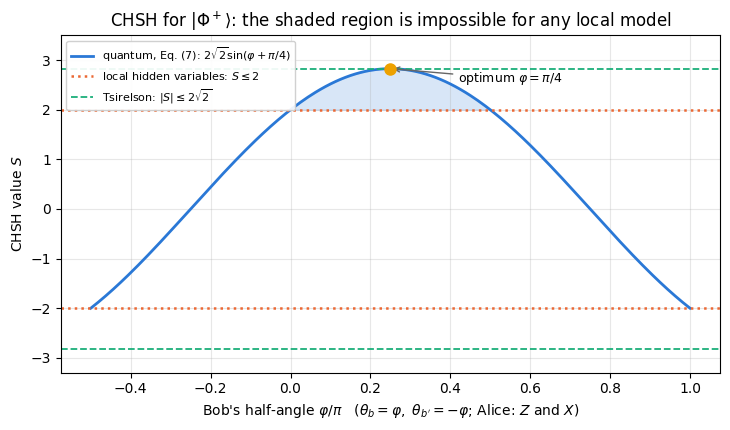

In [10]:
# ==============================================================================
# FIGURE: the CHSH angle curve -- where the quantum prediction leaves the classical polytope
# ==============================================================================
phis_np = np.asarray(phis)
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(phis_np / np.pi, S_sweep, "-", color=PALETTE[0], lw=2, label=r"quantum, Eq. (7): $2\sqrt{2}\sin(\varphi+\pi/4)$")
ax.axhline(2.0, color=PALETTE[1], ls=":", lw=1.8, label="local hidden variables: $S\\leq 2$")
ax.axhline(-2.0, color=PALETTE[1], ls=":", lw=1.8)
ax.axhline(2 * np.sqrt(2), color=PALETTE[2], ls="--", lw=1.3, label=r"Tsirelson: $|S|\leq 2\sqrt{2}$")
ax.axhline(-2 * np.sqrt(2), color=PALETTE[2], ls="--", lw=1.3)
ax.fill_between(phis_np / np.pi, 2.0, np.maximum(S_sweep, 2.0), where=S_sweep > 2.0,
                color=PALETTE[0], alpha=0.18)
ax.plot([0.25], [2 * np.sqrt(2)], "o", color=PALETTE[3], ms=8, zorder=5)
ax.annotate(r"optimum $\varphi=\pi/4$", xy=(0.25, 2 * np.sqrt(2)), xytext=(0.42, 2.55), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="0.4", lw=1))
ax.set_xlabel(r"Bob's half-angle $\varphi/\pi$   ($\theta_b=\varphi,\ \theta_{b'}=-\varphi$; Alice: $Z$ and $X$)")
ax.set_ylabel(r"CHSH value $S$")
ax.set_ylim(-3.3, 3.5)
ax.set_title(r"CHSH for $|\Phi^+\rangle$: the shaded region is impossible for any local model")
ax.legend(fontsize=8, loc="upper left", frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()

The four correlators are $\pm1/\sqrt2$ as predicted, their CHSH combination is $2\sqrt2$ to machine precision, and the sweep
reproduces Eq. (7) exactly, with its maximum at $\varphi=\pi/4$. The shaded lobe is the whole story of this notebook: for
$0<\varphi<\pi/2$ the quantum prediction lies strictly outside the region accessible to *any* local hidden-variable model, and at
$\varphi=\pi/4$ it touches the absolute quantum ceiling $2\sqrt2$. Everything that follows is about measuring that lobe with real
(finite, noisy, lossy) data.

## 9. Simulating the experiment: shots, settings and PRNG keys

So far every number came from the state vector. A real experiment never sees a state vector: it sees a list of $\pm1$ pairs. We now
reproduce that.

**One run** of the experiment is: pick a setting pair $(\theta_a,\theta_b)$, rotate the state with
$R_y(-\theta_a)\otimes R_y(-\theta_b)$, draw one flat index $s\in\{0,1,2,3\}$ from the Born probabilities, and translate it into the
two outcomes $(-1)^{s_0}$, $(-1)^{s_1}$. The estimator of the correlator from $n$ runs is the sample mean of the product,

$$\hat E=\frac{1}{n}\sum_{k=1}^{n}(-1)^{s_0^{(k)}+s_1^{(k)}} .$$

Because the product is a $\pm1$ random variable with mean $E$, its variance is $\mathrm{Var}=\langle(\pm1)^2\rangle-E^2=1-E^2$, so

$$\mathrm{SE}(\hat E)=\sqrt{\frac{1-E^2}{n}} . \tag{8}$$

The four settings are measured on independent runs, so their estimates are independent and the errors add in quadrature:

$$\mathrm{SE}(\hat S)=\sqrt{\sum_{i=1}^{4}\frac{1-E_i^2}{n}}=\sqrt{\frac{4-\sum_iE_i^2}{n}} . \tag{9}$$

At the optimal settings every $E_i^2=1/2$, so $\mathrm{SE}(\hat S)=\sqrt{2/n}$ — a clean, fully analytic prediction we can test
against the measured scatter.

> **JAX practice.** Two levels of batching appear, and they are *different*. Over the four **settings** we use `jax.vmap`, because
> each setting rotates the state differently — the rotation angles are traced arrays, so the same compiled code serves all four.
> Over **shots** within one setting we have a choice: `jax.random.categorical(key, logits, shape=(n,))` draws all $n$ at once from
> the same probability vector (fast), or we `vmap` a single-shot function over $n$ independent keys (slower, but literally one PRNG
> key per experimental run). We implement both and compare their estimates against the analytic error bar.

In [11]:
# ==============================================================================
# STEP 7: the simulated CHSH experiment -- batched shots and per-shot vmap
# ==============================================================================
def sample_pair_batch(key, psi, theta_a, theta_b, shots):
    """`shots` outcome pairs (+-1, +-1) of measuring A(theta_a) (x) A(theta_b), drawn in ONE categorical call.

    IMPLEMENTATION  log-probabilities -> `jax.random.categorical` (Gumbel-max) -> flat indices s in 0..3;
                    bits are s0 = s >> 1, s1 = s & 1 and the outcome is (-1)^s.
    COST   O(shots) random numbers + 2 einsums on a 4-element tensor.
    """
    p = rotated_probs(psi, theta_a, theta_b)
    idx = jax.random.categorical(key, jnp.log(jnp.clip(p, 1e-300, None)), shape=(shots,))
    return 1 - 2 * (idx >> 1), 1 - 2 * (idx & 1)


def sample_pair_one_shot(key, psi, theta_a, theta_b):
    """ONE experimental run: one PRNG key in, one pair of +-1 outcomes out.  `vmap` it over keys for many shots."""
    p = rotated_probs(psi, theta_a, theta_b)
    idx = jax.random.categorical(key, jnp.log(jnp.clip(p, 1e-300, None)))
    return 1 - 2 * (idx >> 1), 1 - 2 * (idx & 1)


@partial(jax.jit, static_argnums=(2,))
def chsh_sampled(key, psi, shots, settings=SETTINGS_OPT):
    """Estimate S from `shots` runs per setting.  Returns (S_hat, SE_hat, E_hat[4]).

    MATH   E_hat = mean of the outcome products;  SE from Eq. (9) with the SAMPLE variances.
    JAX    one key per setting (`jax.random.split`), `vmap` over the four settings.
    """
    keys = jax.random.split(key, settings.shape[0])

    def one_setting(k, s):
        a, b = sample_pair_batch(k, psi, s[0], s[1], shots)
        par = (a * b).astype(RDTYPE)
        return jnp.mean(par), jnp.var(par) / shots            # (estimate, its variance)

    E, varE = jax.vmap(one_setting)(keys, settings)
    return jnp.sum(CHSH_SIGNS * E), jnp.sqrt(jnp.sum(varE)), E


# --- one simulated experiment --------------------------------------------------------------------------
SHOTS_DEMO = 4000
S_hat, SE_hat, E_hat = chsh_sampled(jax.random.PRNGKey(2024), psi_bell, SHOTS_DEMO)
print(f"ONE SIMULATED EXPERIMENT:  {SHOTS_DEMO} shots per setting, {4 * SHOTS_DEMO} runs in total\n")
print(f"{'setting':>18s} {'E_exact':>10s} {'E_measured':>12s} {'SE (Eq. 8)':>11s}")
for (ta, tb), ee, em in zip(np.asarray(SETTINGS_OPT), np.asarray(E_opt), np.asarray(E_hat)):
    print(f"  ({ta:+.4f},{tb:+.4f}) {ee:10.4f} {em:12.4f} {np.sqrt((1 - ee ** 2) / SHOTS_DEMO):11.4f}")
print(f"\n  S_measured = {float(S_hat):.4f} +- {float(SE_hat):.4f}      "
      f"(exact {2 * np.sqrt(2):.4f}, classical bound 2)")
print(f"  violation  = {(float(S_hat) - 2) / float(SE_hat):.1f} standard errors above 2")
print(f"  analytic SE at the optimum = sqrt(2/n) = {np.sqrt(2 / SHOTS_DEMO):.4f}")

# --- per-shot vmap version: one PRNG key per experimental run -------------------------------------------
@partial(jax.jit, static_argnums=(2,))
def chsh_sampled_pershot(key, psi, shots, settings=SETTINGS_OPT):
    """Same estimate, but literally one key per run: vmap of `sample_pair_one_shot` over `shots` keys."""
    keys = jax.random.split(key, settings.shape[0])

    def one_setting(k, s):
        ks = jax.random.split(k, shots)                         # one key per experimental run
        a, b = jax.vmap(lambda kk: sample_pair_one_shot(kk, psi, s[0], s[1]))(ks)
        return jnp.mean((a * b).astype(RDTYPE))

    E = jax.vmap(one_setting)(keys, settings)
    return jnp.sum(CHSH_SIGNS * E)


S_ps = float(chsh_sampled_pershot(jax.random.PRNGKey(2024), psi_bell, SHOTS_DEMO))
print(f"\n  per-shot vmap version (one key per run): S = {S_ps:.4f}"
      f"   |difference| from the batched version = {abs(S_ps - float(S_hat)):.4f}"
      f"   (both within ~{float(SE_hat):.4f} of {2 * np.sqrt(2):.4f})")

ONE SIMULATED EXPERIMENT:  4000 shots per setting, 16000 runs in total

           setting    E_exact   E_measured  SE (Eq. 8)
  (+0.0000,+0.7854)     0.7071       0.6895      0.0112
  (+0.0000,-0.7854)     0.7071       0.6915      0.0112
  (+1.5708,+0.7854)     0.7071       0.7185      0.0112
  (+1.5708,-0.7854)    -0.7071      -0.7100      0.0112

  S_measured = 2.8095 +- 0.0225      (exact 2.8284, classical bound 2)
  violation  = 36.0 standard errors above 2
  analytic SE at the optimum = sqrt(2/n) = 0.0224



  per-shot vmap version (one key per run): S = 2.8230   |difference| from the batched version = 0.0135   (both within ~0.0225 of 2.8284)


Both samplers produce an estimate compatible with the exact value within the analytic error bar, and the measured standard error
matches $\sqrt{2/n}$. They differ from each other simply because they consume randomness differently — the same physics, different
random draws. From here on we use the batched version, which is much cheaper.

## 10. How many shots do we need? Convergence and the $5\sigma$ question

### 10.1 Planning the experiment

A referee does not accept "we measured $S=2.1$". They accept "we measured $S=2.83\pm0.02$, which is $40$ standard errors above the
classical bound". So: how many runs $n$ per setting are needed for a $k\sigma$ violation? Set the expected excess equal to
$k$ standard errors, using Eq. (9) at the optimum:

$$2\sqrt2-2=k\,\sqrt{\frac{2}{n}}\qquad\Longrightarrow\qquad n=\frac{2k^2}{\left(2\sqrt2-2\right)^2} . \tag{10}$$

For $k=5$ this is $n=50/0.6863=72.9$, i.e. **73 runs per setting, 292 runs in total**. That is a remarkably small number — the
reason Bell tests are hard is not statistics, it is closing the loopholes (Section 13).

Careful with the interpretation, though. Equation (10) makes the *expected* significance equal to $5$; because $\hat S$ itself
fluctuates, roughly half the experiments at $n=73$ will land below $5\sigma$. We measure that fraction below, and also the $n$ at
which a $5\sigma$ result becomes nearly certain.

In [12]:
# ==============================================================================
# STEP 8: convergence of S with the number of shots (vmap over independent experiments)
# ==============================================================================
# PARAMETERS ---------------------------------------------------------------------------------------
SHOT_GRID = np.array([10, 30, 100, 300, 1000, 3000, 10000])   # shots per setting
N_REPEAT = 100                                                 # independent experiments per point
# --------------------------------------------------------------------------------------------------
S_TARGET = 2 * np.sqrt(2)


def significance(S_arr, SE_arr):
    """(S - 2) / SE, guarding against SE = 0 (possible when every shot of a setting gives the same sign)."""
    return (np.asarray(S_arr) - 2.0) / np.maximum(np.asarray(SE_arr), 1e-300)


rows = []
t0 = time.perf_counter()
for j, n in enumerate(SHOT_GRID):
    keys = jax.random.split(jax.random.PRNGKey(100 + j), N_REPEAT)
    S_all, SE_all, _ = jax.vmap(lambda k: chsh_sampled(k, psi_bell, int(n)))(keys)   # vmap over experiments
    S_all, SE_all = np.asarray(S_all), np.asarray(SE_all)
    rows.append((n, S_all.mean(), S_all.std(), SE_all.mean(), np.sqrt(2 / n),
                 float(np.mean(S_all > 2)), float(np.mean(significance(S_all, SE_all) > 5))))
print(f"(vmapped Monte Carlo: {N_REPEAT} experiments per point, {time.perf_counter() - t0:.1f} s)\n")
print(f"{'n/setting':>9s} {'mean S':>8s} {'std(S)':>8s} {'mean SE':>8s} {'sqrt(2/n)':>10s} "
      f"{'P(S>2)':>8s} {'P(>5 sigma)':>12s}")
for n, m, s, se, an, pv, p5 in rows:
    print(f"{n:9d} {m:8.4f} {s:8.4f} {se:8.4f} {an:10.4f} {pv:8.3f} {p5:12.3f}")

n_5sigma = 2 * 25 / (2 * np.sqrt(2) - 2) ** 2
n_plan = int(np.ceil(n_5sigma))
print(f"\n  Eq. (10) for k = 5:  n = 2*25/(2sqrt2-2)^2 = {n_5sigma:.2f}  ->  {n_plan} runs per setting")
keys = jax.random.split(jax.random.PRNGKey(999), 4000)
S73, SE73, _ = jax.vmap(lambda k: chsh_sampled(k, psi_bell, n_plan))(keys)
sig73 = significance(S73, SE73)
print(f"  measured at n = {n_plan} over 4000 experiments:  mean significance = {sig73.mean():.2f} sigma, "
      f"fraction above 5 sigma = {np.mean(sig73 > 5):.3f}, fraction above 2 = {np.mean(np.asarray(S73) > 2):.3f}")
for n_try in (150, 300):
    kk = jax.random.split(jax.random.PRNGKey(n_try), 4000)
    S_t, SE_t, _ = jax.vmap(lambda k: chsh_sampled(k, psi_bell, n_try))(kk)
    print(f"  at n = {n_try:4d}: mean significance = {significance(S_t, SE_t).mean():5.2f} sigma, "
          f"fraction above 5 sigma = {np.mean(significance(S_t, SE_t) > 5):.3f}")

(vmapped Monte Carlo: 100 experiments per point, 17.8 s)

n/setting   mean S   std(S)  mean SE  sqrt(2/n)   P(S>2)  P(>5 sigma)
       10   2.8360   0.3851   0.4190     0.4472    0.970        0.040
       30   2.8300   0.2646   0.2527     0.2582    1.000        0.140
      100   2.8364   0.1374   0.1401     0.1414    1.000        0.750
      300   2.8315   0.0746   0.0814     0.0816    1.000        1.000
     1000   2.8293   0.0383   0.0447     0.0447    1.000        1.000
     3000   2.8296   0.0229   0.0258     0.0258    1.000        1.000
    10000   2.8276   0.0131   0.0141     0.0141    1.000        1.000

  Eq. (10) for k = 5:  n = 2*25/(2sqrt2-2)^2 = 72.86  ->  73 runs per setting


  measured at n = 73 over 4000 experiments:  mean significance = 5.13 sigma, fraction above 5 sigma = 0.500, fraction above 2 = 1.000


  at n =  150: mean significance =  7.27 sigma, fraction above 5 sigma = 0.962


  at n =  300: mean significance = 10.21 sigma, fraction above 5 sigma = 1.000


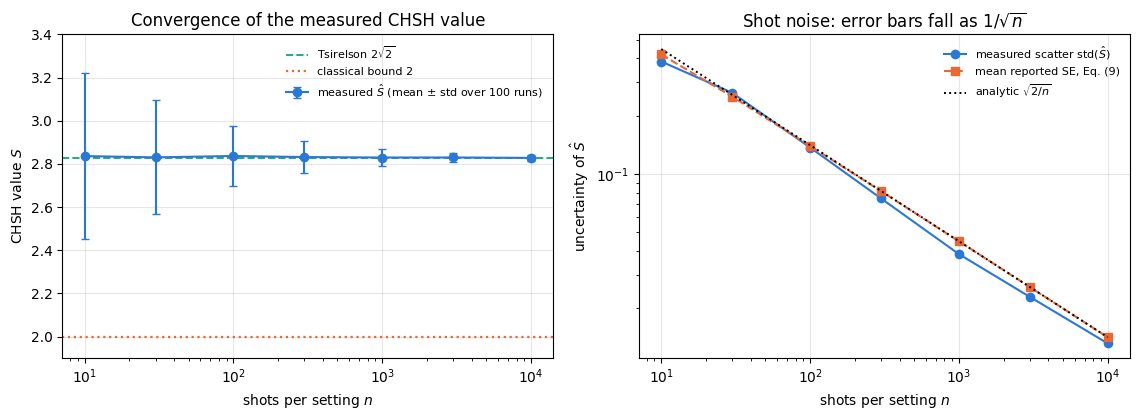

In [13]:
# ==============================================================================
# FIGURE: convergence of the measured S and of its error bar
# ==============================================================================
n_arr = np.array([r[0] for r in rows], dtype=float)
mean_S = np.array([r[1] for r in rows])
std_S = np.array([r[2] for r in rows])
mean_SE = np.array([r[3] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].errorbar(n_arr, mean_S, yerr=std_S, fmt="o-", color=PALETTE[0], capsize=3,
                 label=r"measured $\hat S$ (mean $\pm$ std over %d runs)" % N_REPEAT)
axes[0].axhline(S_TARGET, color=PALETTE[2], ls="--", lw=1.4, label=r"Tsirelson $2\sqrt{2}$")
axes[0].axhline(2.0, color=PALETTE[1], ls=":", lw=1.6, label="classical bound 2")
axes[0].set_xscale("log")
axes[0].set_xlabel("shots per setting $n$")
axes[0].set_ylabel(r"CHSH value $S$")
axes[0].set_ylim(1.90, 3.40)
axes[0].set_title("Convergence of the measured CHSH value")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].loglog(n_arr, std_S, MARKERS[0] + "-", color=PALETTE[0], label=r"measured scatter std$(\hat S)$")
axes[1].loglog(n_arr, mean_SE, MARKERS[1] + "--", color=PALETTE[1], label=r"mean reported SE, Eq. (9)")
axes[1].loglog(n_arr, np.sqrt(2 / n_arr), "k:", lw=1.4, label=r"analytic $\sqrt{2/n}$")
axes[1].set_xlabel("shots per setting $n$")
axes[1].set_ylabel(r"uncertainty of $\hat S$")
axes[1].set_title("Shot noise: error bars fall as $1/\\sqrt{n}$")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

The mean estimate sits on $2\sqrt2$ at every shot number — the
estimator is unbiased — and what shrinks is the scatter. At $n=10$ runs per setting that scatter is $0.39$, about half of the whole
$0.83$ gap between the classical and the quantum bound: $97\%$ of such "experiments" land above $2$, but only $4\%$ of them reach
$5\sigma$, so a single one of them proves very little. By $n=300$ every single experiment in the sample exceeds $5\sigma$.

The right panel is the quantitative statement: the measured scatter over independent experiments, the error bar each experiment
*reports* from its own data via Eq. (9), and the analytic $\sqrt{2/n}$ all follow the same $n^{-1/2}$ line over three decades.
Two small systematic effects are visible and both are understood. First, the reported error bar sits slightly *below*
$\sqrt{2/n}$ ($0.419$ against $0.447$ at $n=10$, $0.1401$ against $0.1414$ at $n=100$, equal to four digits from $n=10^3$ on):
a plug-in variance estimated from $n$ samples is biased low by the factor $\sqrt{(n-1)/n}$, which is $3\%$ at $n=10$ and
$0.05\%$ at $n=10^3$. Second, the measured scatter wanders around $\sqrt{2/n}$ by up to $14\%$ in either direction ($+2\%$ at
$n=30$, $-14\%$ at $n=10$ and at $n=10^3$) with no trend in $n$; that is pure
sampling noise of the scatter itself, since a standard deviation estimated from only $R=100$ experiments carries a relative
uncertainty of about $1/\sqrt{2R}\approx7\%$, so the largest gap is a two-sigma fluctuation. (The exact standard deviation of
$\hat S$ really is $\sqrt{2/n}$ for every $n$, because $\mathrm{Var}(\hat E_i)=(1-E_i^2)/n$ holds exactly for a mean of $\pm1$
draws.) The checkpoint is that the error bar an experiment computes from its own single data set reproduces the scatter of many
independent data sets: neither optimistic nor inflated.

The planning calculation comes out as predicted: Eq. (10) says $73$ runs per setting, and the Monte Carlo over $4000$ experiments
at $n=73$ gives a mean significance of $5.1\sigma$ with exactly $50\%$ of the experiments above $5\sigma$ — the hallmark of a
threshold placed at the *expected* value. If you want a $5\sigma$ result to be nearly certain rather than a coin flip, budget two
to four times more: at $n=150$ the success rate is $96\%$, at $n=300$ it is $100\%$ of our sample.

> **Numerical practice.** The middle column of the table is the one you should internalise. An error bar computed from the sample
> variance of *one* data set (what an experiment can do) reproduces the scatter of many independent data sets (what an experiment
> cannot do). That is the entire content of the phrase "the standard error".

## 11. Werner states: entanglement is not the same as nonlocality

Real sources are noisy. The standard one-parameter family of noisy Bell pairs is the **Werner state** (Werner 1989), a Bell state
mixed with white noise:

$$\rho_W(v)=v\,\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v)\,\frac{\mathbb 1_4}{4},\qquad v\in[0,1] .$$

$v$ is called the **visibility**. (Werner's original state is written with the singlet. The two families are related by the local
unitary $\mathbb 1\otimes(-iY)$, which maps $\vert\Phi^+\rangle$ to $\vert\Psi^-\rangle$ and leaves $\mathbb 1/4$ alone, so they
have identical entanglement and CHSH properties.)

Three thresholds live in this one line, and they are *different numbers*.

**(a) Correlations.** Linearity of the correlators gives $T_W=v\,T_{\Phi^+}$, because the maximally mixed state has all
$\langle\sigma_i\sigma_j\rangle=0$. Hence $E_W=v\cos(\theta_a-\theta_b)$ and, by Eq. (6) with $t_1=t_2=v$,

$$S_{\max}(v)=2\sqrt2\,v\quad\Longrightarrow\quad\text{CHSH violation}\iff v>\frac{1}{\sqrt2}\approx0.7071 .$$

**(b) Entanglement.** Use the PPT (Peres–Horodecki) criterion, implemented by the engine's `negativity`: the partial transpose of
$\vert\Phi^+\rangle\langle\Phi^+\vert$ has eigenvalues $(\tfrac12,\tfrac12,\tfrac12,-\tfrac12)$, so
$\rho_W^{T_A}$ has eigenvalues $\tfrac{1-v}{4}+v\cdot(\pm\tfrac12)$, i.e. $\tfrac{1+v}{4}$ (three times) and $\tfrac{1-3v}{4}$.
One eigenvalue is negative exactly when

$$v>\frac{1}{3},\qquad \mathcal N(\rho_W)=\max\left(0,\frac{3v-1}{4}\right) .$$

**(c) The gap.** For $\tfrac13<v\le\tfrac{1}{\sqrt2}$ the state is **entangled but does not violate CHSH**. This is not a failure of
our search over angles: Werner constructed an explicit local hidden-variable model that reproduces *all* projective measurements on
these states for $v\le\tfrac12$. So entanglement and Bell nonlocality are genuinely different resources — nonlocality is strictly
stronger, and a CHSH test is a *sufficient* but not necessary entanglement witness.

On a density tensor, mixing with the identity and measuring correlators uses `apply_gate_dm` (the same einsum applied to the ket and
the conjugated bra axes) and the diagonal of the rotated density matrix.

In [14]:
# ==============================================================================
# STEP 9: CHSH and entanglement of Werner states, on the density TENSOR
# ==============================================================================
def werner_state(v, kind="phi+"):
    """Werner / isotropic state  rho = v |B><B| + (1-v) 1/4,  as a rank-4 density TENSOR."""
    rho_pure = to_dm(bell_state(kind))                                   # shape (2,2,2,2)
    identity = jnp.eye(4, dtype=CDTYPE).reshape(2, 2, 2, 2) / 4.0
    return v * rho_pure + (1 - v) * identity


def rotated_probs_dm(rho, theta_a, theta_b):
    """Outcome probabilities p(s0,s1) for a density TENSOR: rotate both qubits, read the diagonal.

    MATH   p(s) = [ (Ry(-ta) (x) Ry(-tb)) rho (h.c.) ]_{ss} ;  `apply_gate_dm` = U on ket axes, U^* on bra axes.
    """
    r = apply_gate_dm(rho, ry(-theta_a), [0])
    r = apply_gate_dm(r, ry(-theta_b), [1])
    return jnp.real(jnp.diag(dm_matrix(r)))


def chsh_exact_dm(rho, settings=SETTINGS_OPT):
    """Exact CHSH value of a density tensor for four settings (vmap over settings)."""
    E = jax.vmap(lambda s: corr_from_probs(rotated_probs_dm(rho, s[0], s[1])))(settings)
    return jnp.sum(CHSH_SIGNS * E), E


def correlation_matrix_dm(rho):
    """T[i,j] = Tr(rho sigma_i (x) sigma_j) for a density tensor (matrix-free Pauli strings)."""
    return jnp.array([[expect_pauli_string_dm(rho, p + q) for q in PAULI_AXES] for p in PAULI_AXES])


def chsh_max(T):
    """Horodecki criterion, Eq. (6):  S_max = 2 sqrt(t1^2 + t2^2), t1 >= t2 the two largest singular values of T."""
    s = jnp.linalg.svd(T, compute_uv=False)
    return 2 * jnp.sqrt(s[0] ** 2 + s[1] ** 2)


v_grid = np.linspace(0.0, 1.0, 51)
S_w = np.array([float(chsh_exact_dm(werner_state(float(v)))[0]) for v in v_grid])
Smax_w = np.array([float(chsh_max(correlation_matrix_dm(werner_state(float(v))))) for v in v_grid])
neg_w = np.array([float(negativity(werner_state(float(v)), [0])[0]) for v in v_grid])

print(f"{'v':>6s} {'S (fixed angles)':>17s} {'S_max (Horodecki)':>18s} {'2*sqrt(2)*v':>12s} "
      f"{'negativity':>11s} {'(3v-1)/4':>9s}")
for v in [0.0, 0.2, 1 / 3, 0.5, 0.6, 1 / np.sqrt(2), 0.8, 0.9, 1.0]:
    rho = werner_state(float(v))
    S_v = float(chsh_exact_dm(rho)[0])
    Sm = float(chsh_max(correlation_matrix_dm(rho)))
    ng = float(negativity(rho, [0])[0])
    print(f"{v:6.4f} {S_v:17.6f} {Sm:18.6f} {2 * np.sqrt(2) * v:12.6f} {ng:11.6f} {max(0.0, (3 * v - 1) / 4):9.6f}")

err_S = max(abs(float(chsh_exact_dm(werner_state(float(v)))[0]) - 2 * np.sqrt(2) * v) for v in v_grid)
err_N = max(abs(float(negativity(werner_state(float(v)), [0])[0]) - max(0.0, (3 * v - 1) / 4)) for v in v_grid)
print(f"\nCHECKPOINT  max|S(v) - 2sqrt(2) v| = {err_S:.2e};  max|negativity - max(0,(3v-1)/4)| = {err_N:.2e}")
assert err_S < 1e3 * TOL and err_N < 1e3 * TOL

     v  S (fixed angles)  S_max (Horodecki)  2*sqrt(2)*v  negativity  (3v-1)/4
0.0000          0.000000           0.000000     0.000000    0.000000  0.000000
0.2000          0.565685           0.565685     0.565685    0.000000  0.000000
0.3333          0.942809           0.942809     0.942809    0.000000  0.000000
0.5000          1.414214           1.414214     1.414214    0.125000  0.125000
0.6000          1.697056           1.697056     1.697056    0.200000  0.200000
0.7071          2.000000           2.000000     2.000000    0.280330  0.280330
0.8000          2.262742           2.262742     2.262742    0.350000  0.350000
0.9000          2.545584           2.545584     2.545584    0.425000  0.425000


1.0000          2.828427           2.828427     2.828427    0.500000  0.500000



CHECKPOINT  max|S(v) - 2sqrt(2) v| = 1.33e-15;  max|negativity - max(0,(3v-1)/4)| = 1.67e-16


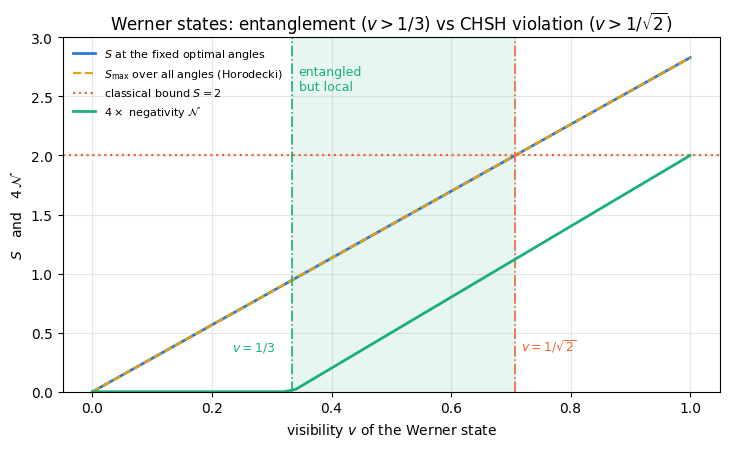

In [15]:
# ==============================================================================
# FIGURE: the two Werner thresholds -- entanglement at v = 1/3, nonlocality at v = 1/sqrt(2)
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(v_grid, S_w, "-", color=PALETTE[0], lw=2, label=r"$S$ at the fixed optimal angles")
ax.plot(v_grid, Smax_w, "--", color=PALETTE[3], lw=1.6, label=r"$S_{\max}$ over all angles (Horodecki)")
ax.axhline(2.0, color=PALETTE[1], ls=":", lw=1.6, label="classical bound $S=2$")
ax.axvline(1 / np.sqrt(2), color=PALETTE[1], ls="-.", lw=1.2)
ax.axvline(1 / 3, color=PALETTE[2], ls="-.", lw=1.2)
ax.plot(v_grid, 4 * neg_w, "-", color=PALETTE[2], lw=2, label=r"$4\times$ negativity $\mathcal{N}$")
ax.fill_betweenx([0, 3], 1 / 3, 1 / np.sqrt(2), color=PALETTE[2], alpha=0.10)
ax.text(0.345, 2.55, "entangled\nbut local", fontsize=9, color=PALETTE[2])
ax.text(1 / np.sqrt(2) + 0.01, 0.35, r"$v=1/\sqrt{2}$", fontsize=9, color=PALETTE[1])
ax.text(1 / 3 - 0.10, 0.35, r"$v=1/3$", fontsize=9, color=PALETTE[2])
ax.set_xlabel("visibility $v$ of the Werner state")
ax.set_ylabel(r"$S$   and   $4\,\mathcal{N}$")
ax.set_ylim(0, 3.0)
ax.set_title(r"Werner states: entanglement ($v>1/3$) vs CHSH violation ($v>1/\sqrt{2}$)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

Both curves are straight lines in $v$, and the fixed-angle and re-optimised values coincide
everywhere — for an isotropic mixture the optimal angles do not move, because white noise shrinks all three axes of $T$ equally.
The printed table confirms $S=2\sqrt2\,v$ and $\mathcal N=\max(0,(3v-1)/4)$ to machine precision, so the two crossings are exactly
at $v=1/\sqrt2$ and $v=1/3$. The shaded strip between them is the physically interesting region: those states are entangled (the
negativity is positive, and one can distil and teleport with them — see the next notebook) yet no CHSH experiment will ever see
anything non-classical in them.

> **Physics insight.** "Entangled" is a statement about the *state* (it is not a tensor product of local states). "Nonlocal" is a
> statement about the *correlations it can produce* (they do not fit into any LHV model). The second is strictly stronger.
> A device that fails a CHSH test may still be perfectly useful.

## 12. CHSH under realistic noise

Werner noise is a convenient caricature. Real hardware applies *channels* to each qubit. We take the three standard single-qubit
channels from [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)
and apply them to **both** qubits of $\vert\Phi^+\rangle$ with the same strength $p$:

* **depolarising**, $\rho\to(1-p)\rho+\tfrac{p}{3}(X\rho X+Y\rho Y+Z\rho Z)$: the Bloch vector shrinks isotropically by
  $\eta=1-\tfrac{4p}{3}$;
* **dephasing**, $\rho\to(1-p)\rho+pZ\rho Z$: $Z$ survives, $X$ and $Y$ shrink by $1-2p$;
* **amplitude damping** with rate $p$: population flows to $\vert0\rangle$, which also produces non-zero local Bloch vectors.

**Predictions we can make by hand.** A single-qubit channel acts on the Bloch vector as the affine map
$\mathbf r\to\Lambda\mathbf r+\mathbf t$, with $\Lambda$ the $3\times3$ contraction and $\mathbf t$ the displacement
($\mathbf t=0$ for unital channels such as depolarising and dephasing). Since $\langle\sigma_i\otimes\sigma_j\rangle$ is linear in
each qubit's Bloch components, and since $\vert\Phi^+\rangle$ has zero local Bloch vectors, the correlation matrix transforms as

$$T\longrightarrow\Lambda_0\,T\,\Lambda_1^{\mathsf T}+\mathbf t_0\,\mathbf t_1^{\mathsf T} .$$

So:

* depolarising on both qubits: $T\to\eta^2\,T$, hence $S=2\sqrt2\,\eta^2$ and the violation dies at $\eta^2=1/\sqrt2$, i.e.
  $\eta=2^{-1/4}$ and $p_{\rm crit}=\tfrac34\left(1-2^{-1/4}\right)\approx0.1193$;
* dephasing on both qubits: $T\to\mathrm{diag}(\lambda,\lambda,1)\,T$ with $\lambda=(1-2p)^2$ (one factor $1-2p$ per qubit).
  At the *fixed* angles of Section 8, $S=\sqrt2\,(1+\lambda)$, which crosses 2 at $\lambda=\sqrt2-1$, i.e.
  $p=\tfrac12\left(1-\sqrt{\sqrt2-1}\right)\approx0.1782$.
  But if we **re-optimise the angles**, Eq. (6) with $t_1=1$, $t_2=\lambda$ gives
  $S_{\max}=2\sqrt{1+\lambda^2}=2\sqrt{1+(1-2p)^4}>2$ for *every* $p<1/2$: a dephased Bell pair violates CHSH at any
  dephasing strength short of $p=1/2$, provided you turn the knobs to the right place. Only at $p=1/2$, where the coherence is
  gone and $\lambda=0$, does $S_{\max}$ fall to exactly $2$;
* **amplitude damping** with rate $p$ is the one channel with a non-zero local Bloch vector, $\mathbf{t}=(0,0,p)$ and
  $\Lambda=\mathrm{diag}(\sqrt{1-p},\sqrt{1-p},1-p)$, and the constant part feeds back into the correlations:
  $T\to\Lambda T\Lambda+\mathbf{t}\,\mathbf{t}^{\mathsf T}=\mathrm{diag}\!\left(1-p,\,-(1-p),\,(1-p)^2+p^2\right)$.
  At the fixed angles $S=\sqrt2\left[(1-p)^2+p^2+1-p\right]$, which reaches 2 at the root of $2p^2-3p+2-\sqrt2=0$,
  $p=\tfrac14\left(3-\sqrt{8\sqrt2-7}\right)\approx0.2308$; re-optimised, the two largest singular values are both $1-p$ for
  $p$ in this range, so $S_{\max}=2\sqrt2\,(1-p)$ and the violation ends at $p=1-1/\sqrt2\approx0.2929$.

The dephasing case is a genuine lesson about experiments: the critical noise level is a property of the *protocol*, not only of the
state. We measure all of it below.

In [16]:
# ==============================================================================
# STEP 10: CHSH under depolarising / dephasing / amplitude-damping noise on both qubits
# ==============================================================================
CHANNELS = {"depolarising": kraus_depolarizing, "dephasing": kraus_dephasing,
            "amplitude damping": kraus_amplitude_damping}


def noisy_bell(p, channel):
    """|Phi+> as a density tensor, with the same single-qubit channel applied to BOTH qubits."""
    rho = to_dm(bell_state("phi+"))
    K = CHANNELS[channel](p)
    for q in (0, 1):
        rho = apply_kraus_dm(rho, K, [q])
    return rho


p_grid = np.linspace(0.0, 0.5, 51)
curves = {}
for name in CHANNELS:
    S_fix, S_max, neg = [], [], []
    for p in p_grid:
        rho = noisy_bell(float(p), name)
        S_fix.append(float(chsh_exact_dm(rho)[0]))
        S_max.append(float(chsh_max(correlation_matrix_dm(rho))))
        neg.append(float(negativity(rho, [0])[0]))
    curves[name] = (np.array(S_fix), np.array(S_max), np.array(neg))

print(f"{'p':>6s} | " + " | ".join(f"{n[:11]:>11s} (fix/max)" for n in CHANNELS))
for p in [0.0, 0.02, 0.05, 0.10, 0.12, 0.15, 0.20, 0.30, 0.50]:
    cells = []
    for name in CHANNELS:
        rho = noisy_bell(float(p), name)
        cells.append(f"{float(chsh_exact_dm(rho)[0]):8.4f}/{float(chsh_max(correlation_matrix_dm(rho))):8.4f}")
    print(f"{p:6.3f} | " + " | ".join(cells))


def crossing(x, y, level=2.0):
    """First x where the decreasing curve y(x) crosses `level`, by linear interpolation (nan if it never does)."""
    below = np.flatnonzero(y < level)
    if below.size == 0 or below[0] == 0:
        return np.nan
    i = below[0]
    return x[i - 1] + (y[i - 1] - level) * (x[i] - x[i - 1]) / (y[i - 1] - y[i])


def fmt_crit(x):
    """Format a critical noise level; 'none' if the curve never drops to the classical bound on the grid."""
    return "   none" if not np.isfinite(x) else f"{x:6.4f}"


# Closed forms derived in the markdown above (nan = the curve never reaches 2 for p <= 1/2).
P_CRIT_ANALYTIC = {
    "depolarising":      (0.75 * (1 - 2 ** -0.25), 0.75 * (1 - 2 ** -0.25)),        # 1 - 4p/3 = 2^(-1/4)
    "dephasing":         ((1 - np.sqrt(np.sqrt(2) - 1)) / 2, np.nan),               # (1-2p)^2 = sqrt(2) - 1 ; never for S_max
    "amplitude damping": ((3 - np.sqrt(8 * np.sqrt(2) - 7)) / 4, 1 - 1 / np.sqrt(2)),   # 2p^2-3p+2-sqrt2=0 ; 1-p = 1/sqrt2
}

print("\nCritical noise strength at which the violation disappears (S = 2):")
print(f"  {'channel':18s}  {'fixed angles':>22s}  {'re-optimised angles':>26s}")
for name in CHANNELS:
    S_fix, S_max, _ = curves[name]
    a_fix, a_max = P_CRIT_ANALYTIC[name]
    print(f"  {name:18s}  p_crit = {fmt_crit(crossing(p_grid, S_fix))} [{fmt_crit(a_fix)}]"
          f"   p_crit = {fmt_crit(crossing(p_grid, S_max))} [{fmt_crit(a_max)}]     (analytic in brackets)")

# --- CHECKPOINT: the measured crossings agree with the closed forms ------------------------------------
# The grid spacing is 0.01, and `crossing` interpolates linearly through a curve with non-zero curvature,
# so a residual of order (dp)^2 * S'' ~ 1e-4 is expected; 5e-3 is a comfortable but still meaningful bound.
err_crit = 0.0
for name in CHANNELS:
    S_fix, S_max, _ = curves[name]
    for measured, analytic in zip((crossing(p_grid, S_fix), crossing(p_grid, S_max)), P_CRIT_ANALYTIC[name]):
        assert np.isnan(measured) == np.isnan(analytic), f"{name}: crossing/no-crossing disagreement"
        if np.isfinite(analytic):
            err_crit = max(err_crit, abs(measured - analytic))
print(f"\nCHECKPOINT  max|measured p_crit - analytic p_crit| over the five finite crossings = {err_crit:.2e}")
assert err_crit < 5e-3
# dephasing with re-optimised angles: S_max = 2 sqrt(1 + (1-2p)^4) >= 2 for every p, with equality only at p = 1/2
lam2 = (1 - 2 * p_grid) ** 4
err_deph = np.max(np.abs(curves["dephasing"][1] - 2 * np.sqrt(1 + lam2)))
print(f"            max|S_max(dephasing) - 2 sqrt(1 + (1-2p)^4)| = {err_deph:.2e}   "
      f"(min over the grid = {curves['dephasing'][1].min():.6f} >= 2)")
assert err_deph < 1e3 * TOL and curves["dephasing"][1].min() >= 2.0 - 1e3 * TOL

     p | depolarisin (fix/max) |   dephasing (fix/max) | amplitude d (fix/max)
 0.000 |   2.8284/  2.8284 |   2.8284/  2.8284 |   2.8284/  2.8284
 0.020 |   2.6796/  2.6796 |   2.7176/  2.7198 |   2.7447/  2.7719
 0.050 |   2.4639/  2.4639 |   2.5597/  2.5738 |   2.6234/  2.6870


 0.100 |   2.1245/  2.1245 |   2.3193/  2.3745 |   2.4324/  2.5456
 0.120 |   1.9957/  1.9957 |   2.2311/  2.3097 |   2.3600/  2.4890
 0.150 |   1.8102/  1.8102 |   2.1072/  2.2272 |   2.2557/  2.4042
 0.200 |   1.5211/  1.5211 |   1.9233/  2.1257 |   2.0930/  2.2627


 0.300 |   1.0182/  1.0182 |   1.6405/  2.0254 |   1.8102/  1.9799
 0.500 |   0.3143/  0.3143 |   1.4142/  2.0000 |   1.4142/  1.4142

Critical noise strength at which the violation disappears (S = 2):
  channel                       fixed angles         re-optimised angles
  depolarising        p_crit = 0.1193 [0.1193]   p_crit = 0.1193 [0.1193]     (analytic in brackets)
  dephasing           p_crit = 0.1782 [0.1782]   p_crit =    none [   none]     (analytic in brackets)
  amplitude damping   p_crit = 0.2308 [0.2308]   p_crit = 0.2929 [0.2929]     (analytic in brackets)

CHECKPOINT  max|measured p_crit - analytic p_crit| over the five finite crossings = 2.27e-05
            max|S_max(dephasing) - 2 sqrt(1 + (1-2p)^4)| = 1.33e-15   (min over the grid = 2.000000 >= 2)


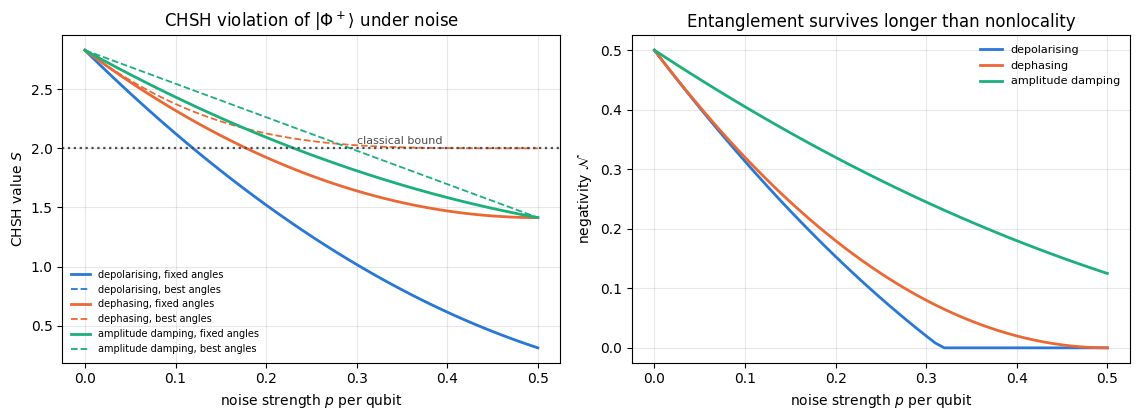

In [17]:
# ==============================================================================
# FIGURE: CHSH value and entanglement vs noise strength, three channels
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharex=True)
for k, name in enumerate(CHANNELS):
    S_fix, S_max, neg = curves[name]
    axes[0].plot(p_grid, S_fix, "-", color=PALETTE[k], lw=2, label=f"{name}, fixed angles")
    axes[0].plot(p_grid, S_max, "--", color=PALETTE[k], lw=1.3, label=f"{name}, best angles")
    axes[1].plot(p_grid, neg, "-", color=PALETTE[k], lw=2, label=name)
axes[0].axhline(2.0, color="0.3", ls=":", lw=1.6)
axes[0].text(0.30, 2.04, "classical bound", fontsize=8, color="0.3")
axes[0].set_xlabel("noise strength $p$ per qubit")
axes[0].set_ylabel(r"CHSH value $S$")
axes[0].set_title(r"CHSH violation of $|\Phi^+\rangle$ under noise")
axes[0].legend(fontsize=7, loc="lower left")
axes[1].set_xlabel("noise strength $p$ per qubit")
axes[1].set_ylabel(r"negativity $\mathcal{N}$")
axes[1].set_title("Entanglement survives longer than nonlocality")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

Read the table and the figure together.

* **Depolarising** noise is exactly the Werner case in disguise: the two curves (fixed and re-optimised angles) coincide, the
  measured critical noise matches the hand calculation $p_{\rm crit}=\tfrac34(1-2^{-1/4})$, and the violation disappears well before
  the entanglement does.
* **Dephasing** shows the protocol dependence announced above: with the angles frozen at $\pi/4$ the violation dies at
  $p=0.1782$, exactly the predicted $\tfrac12\left(1-\sqrt{\sqrt2-1}\right)$; but re-optimising Bob's angles keeps $S$ above 2 all
  the way to $p=1/2$ (at $p=0.30$ the re-optimised value is still $2.025$ while the fixed-angle value has fallen to $1.641$), where
  the coherence vanishes entirely and $S_{\max}$ touches exactly 2. If you only ever turn the knobs to the textbook positions, you
  will conclude that your source is classical when it is not.
* **Amplitude damping** is the most benign of the three at small $p$ — at $p=0.02$ it still gives $S=2.745$ against $2.717$ for
  dephasing and $2.680$ for depolarising — and it survives to $p=0.2308$ at fixed angles, $p=0.2929$ with the angles re-optimised,
  both matching the closed forms $\tfrac14(3-\sqrt{8\sqrt2-7})$ and $1-1/\sqrt2$. It is also the only
  channel here that produces non-zero local Bloch vectors, since it pushes both qubits towards $\vert0\rangle$.
* In every case the negativity in the right panel stays positive after $S$ has dropped below 2 — the "entangled but local" region
  of Section 11 reappears for every noise model.

## 13. The detection loophole

Everything above assumed that every run produces a result. Real detectors miss particles. Suppose each side registers its particle
with probability $\eta$ (the **detection efficiency**) and otherwise reports nothing. The experimenter must do something with the
non-events, and the two standard choices are:

1. **Post-select** on coincidences (discard runs where either side failed) — this assumes that the detected sub-ensemble is a *fair
   sample* of all pairs. That assumption is exactly what a hidden-variable model is allowed to violate: $\lambda$ could tell the
   particle to "not be detected" precisely when the setting is inconvenient.
2. **Assign a fixed outcome** (say $+1$) to every non-event. Then every run yields a result, the CHSH derivation of Section 5
   applies verbatim, and no fair-sampling assumption is needed — but the assigned outcomes dilute the correlations.

Take route 2 and compute what it does to a maximally entangled pair. The effective outcome is $A_{\rm eff}=A$ with probability
$\eta$ and $+1$ with probability $1-\eta$, independently on each side, so

$$E_{\rm eff}=\eta^2E+\eta(1-\eta)\langle A\rangle+(1-\eta)\eta\langle B\rangle+(1-\eta)^2 .$$

For a Bell state the local marginals vanish, $\langle A\rangle=\langle B\rangle=0$, leaving $E_{\rm eff}=\eta^2E+(1-\eta)^2$.
The constant $(1-\eta)^2$ enters the CHSH combination with the sign pattern $+\,+\,+\,-$, i.e. with total weight $2$:

$$S_{\rm eff}(\eta)=2\sqrt2\,\eta^2+2\,(1-\eta)^2 . \tag{11}$$

Setting $S_{\rm eff}=2$ gives $\sqrt2\,\eta^2+(1-\eta)^2=1$, i.e. $\eta^2(1+\sqrt2)=2\eta$, so

$$\eta_{\rm crit}=\frac{2}{1+\sqrt2}=2\left(\sqrt2-1\right)\approx0.8284 .$$

**Below $83\%$ detection efficiency a maximally entangled pair can no longer demonstrate nonlocality this way.** The threshold
is tight: Garg and Mermin showed that at $\eta<2(\sqrt2-1)$ an explicit local model reproduces the post-selected data of route 1,
so route 1 proves nothing there either (we do not construct that model here). This is the *detection loophole*; it is why the 1980s
photon experiments, with efficiencies of a few percent, were not conclusive on their own, and why the loophole-free experiments of
2015 (Hensen and co-workers with entangled spins in diamond, and the photonic experiments of Giustina and of Shalm later the same
year) were such an achievement. Eberhard showed in 1993 that with *non-maximally* entangled states and a different inequality the requirement can be
relaxed to $\eta>2/3$ — one of the rare cases where less entanglement is better.

We simulate route 2 directly: draw the outcomes, draw a detection flag per side per run, and replace the undetected outcome by $+1$
with `jnp.where` — no Python `if` on random data, so the whole thing stays inside `jit` and `vmap`.

In [18]:
# ==============================================================================
# STEP 11: simulating imperfect detectors (undetected -> assign +1)
# ==============================================================================
@partial(jax.jit, static_argnums=(3,))
def chsh_with_losses(key, psi, eta, shots, settings=SETTINGS_OPT):
    """CHSH estimate when each side detects with probability `eta` and reports +1 otherwise.

    JAX   `eta` is a traced scalar; the outcome assignment is `jnp.where`, never a Python `if`.
    """
    keys = jax.random.split(key, settings.shape[0])

    def one_setting(k, s):
        k_out, k_da, k_db = jax.random.split(k, 3)
        a, b = sample_pair_batch(k_out, psi, s[0], s[1], shots)
        det_a = jax.random.bernoulli(k_da, eta, (shots,))          # True = Alice's detector fired
        det_b = jax.random.bernoulli(k_db, eta, (shots,))
        a_eff = jnp.where(det_a, a, 1)                             # non-event -> assign the outcome +1
        b_eff = jnp.where(det_b, b, 1)
        par = (a_eff * b_eff).astype(RDTYPE)
        return jnp.mean(par), jnp.var(par) / shots

    E, varE = jax.vmap(one_setting)(keys, settings)
    return jnp.sum(CHSH_SIGNS * E), jnp.sqrt(jnp.sum(varE))


# PARAMETERS ---------------------------------------------------------------------------------------
ETA_GRID = jnp.linspace(0.5, 1.0, 26)
SHOTS_ETA = 20000
# --------------------------------------------------------------------------------------------------
keys_eta = jax.random.split(jax.random.PRNGKey(31), ETA_GRID.size)
S_eta, SE_eta = jax.vmap(lambda k, e: chsh_with_losses(k, psi_bell, e, SHOTS_ETA))(keys_eta, ETA_GRID)
S_eta, SE_eta, eta_np = np.asarray(S_eta), np.asarray(SE_eta), np.asarray(ETA_GRID)
S_eta_theory = 2 * np.sqrt(2) * eta_np ** 2 + 2 * (1 - eta_np) ** 2
eta_crit = 2 / (1 + np.sqrt(2))

print(f"{'eta':>6s} {'S simulated':>12s} {'SE':>8s} {'S Eq. (11)':>11s} {'violation?':>11s}")
for e, s, se, th in zip(eta_np[::5], S_eta[::5], SE_eta[::5], S_eta_theory[::5]):
    print(f"{e:6.3f} {s:12.4f} {se:8.4f} {th:11.4f} {'yes' if s - 2 > 3 * se else 'no':>11s}")
print(f"\n  max |simulated - Eq. (11)| over the grid = {np.max(np.abs(S_eta - S_eta_theory)):.4f}  "
      f"(typical SE = {SE_eta.mean():.4f})")
print(f"  critical efficiency:  from the simulated points = {np.interp(2.0, S_eta, eta_np):.4f}"
      f"   from Eq. (11) = {np.interp(2.0, S_eta_theory, eta_np):.4f}"
      f"   analytic 2/(1+sqrt(2)) = {eta_crit:.4f}")

# --- CHECKPOINT: the sampled curve agrees with Eq. (11) within shot noise ------------------------------
# The worst of 26 independent points is expected around 2-3 standard errors; 5 is a bound that a genuine
# error in the loss model (e.g. assigning -1, or applying the loss to only one side) would break by far.
z_max = float(np.max(np.abs(S_eta - S_eta_theory) / SE_eta))
print(f"\nCHECKPOINT  largest |simulated - Eq. (11)| in units of its own standard error = {z_max:.2f} sigma")
assert z_max < 5.0

   eta  S simulated       SE  S Eq. (11)  violation?
 0.500       1.1966   0.0131      1.2071          no
 0.600       1.3106   0.0132      1.3382          no
 0.700       1.5542   0.0130      1.5659          no
 0.800       1.8754   0.0125      1.8902          no
 0.900       2.3019   0.0116      2.3110         yes
 1.000       2.8361   0.0100      2.8284         yes

  max |simulated - Eq. (11)| over the grid = 0.0279  (typical SE = 0.0123)
  critical efficiency:  from the simulated points = 0.8251   from Eq. (11) = 0.8283   analytic 2/(1+sqrt(2)) = 0.8284

CHECKPOINT  largest |simulated - Eq. (11)| in units of its own standard error = 2.19 sigma


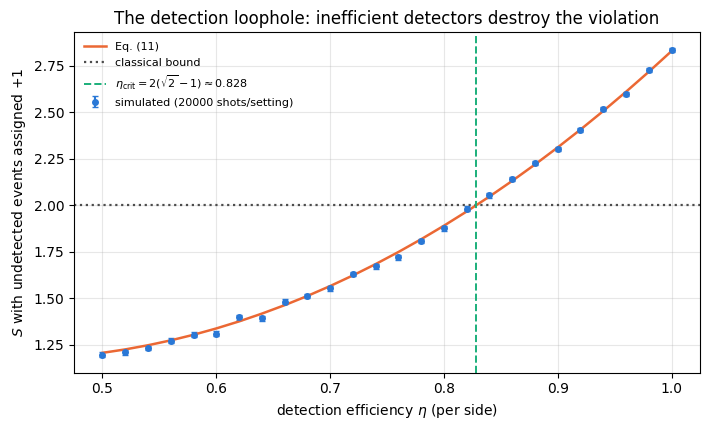

In [19]:
# ==============================================================================
# FIGURE: the detection loophole -- S versus detector efficiency
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.errorbar(eta_np, S_eta, yerr=SE_eta, fmt="o", color=PALETTE[0], ms=4, capsize=2,
            label=f"simulated ({SHOTS_ETA} shots/setting)")
ax.plot(eta_np, S_eta_theory, "-", color=PALETTE[1], lw=1.8, label="Eq. (11)")
ax.axhline(2.0, color="0.3", ls=":", lw=1.6, label="classical bound")
ax.axvline(eta_crit, color=PALETTE[2], ls="--", lw=1.4,
           label=r"$\eta_{\rm crit}=2(\sqrt{2}-1)\approx0.828$")
ax.set_xlabel(r"detection efficiency $\eta$ (per side)")
ax.set_ylabel(r"$S$ with undetected events assigned $+1$")
ax.set_title("The detection loophole: inefficient detectors destroy the violation")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

The simulated points track Eq. (11) across the whole range — the largest deviation anywhere
on the grid is $0.028$, about two standard errors, which is what one expects for the worst of 26 independent points — and the
simulated crossing of the classical bound, $\eta=0.825$, agrees with the analytic $\eta_{\rm crit}=2(\sqrt2-1)=0.8284$ to within
the shot noise. At $\eta=1$ we recover $2\sqrt2$; at $\eta=0$ the
assignment makes every outcome $+1$, every correlator $+1$, and $S=1+1+1-1=2$ — a *deterministic local* strategy sitting exactly on
the classical face, which is precisely why no loophole-free conclusion is possible without high efficiency.

## 14. Performance: why `vmap` and `jit` matter even for two qubits

Two qubits are tiny, so the arithmetic is nothing; what costs time is the *number of Python-level operations*. The Monte-Carlo study
of Section 10 ran $100$ experiments $\times$ $4$ settings $\times$ up to $10^4$ shots at each of seven shot numbers, plus three
ensembles of $4000$ experiments for the sample-size planning. Doing that with a Python loop means
millions of interpreter steps; `vmap` turns the loop into one array axis and `jit` compiles the whole thing into a single XLA
program. We measure the difference. (Timing rules: call once to trigger compilation, then take the best of several runs, and always
`block_until_ready` — JAX is asynchronous and would otherwise time only the dispatch.)

In [20]:
# ==============================================================================
# BENCHMARK: python loop over experiments vs vmap; compile time vs run time
# ==============================================================================
BENCH_SHOTS, BENCH_REPEAT = 1000, 200


def loop_version(key, n_exp):
    """The same Monte Carlo written as a Python loop over experiments (each one still jitted internally)."""
    out = []
    for k in jax.random.split(key, n_exp):
        out.append(chsh_sampled(k, psi_bell, BENCH_SHOTS)[0])
    return jnp.stack(out)


vmap_version = jax.jit(lambda k: jax.vmap(lambda kk: chsh_sampled(kk, psi_bell, BENCH_SHOTS)[0])(
    jax.random.split(k, BENCH_REPEAT)))

t0 = time.perf_counter(); r_v = vmap_version(jax.random.PRNGKey(0)); r_v.block_until_ready()
t_compile = time.perf_counter() - t0
best = np.inf
for _ in range(3):
    t0 = time.perf_counter(); vmap_version(jax.random.PRNGKey(1)).block_until_ready()
    best = min(best, time.perf_counter() - t0)
t0 = time.perf_counter(); r_l = loop_version(jax.random.PRNGKey(1), BENCH_REPEAT); r_l.block_until_ready()
t_loop = time.perf_counter() - t0

print(f"{BENCH_REPEAT} independent CHSH experiments, {BENCH_SHOTS} shots per setting "
      f"({BENCH_REPEAT * 4 * BENCH_SHOTS} simulated runs in total)")
print(f"  vmap + jit : {t_compile * 1e3:8.1f} ms first call (incl. compilation), {best * 1e3:8.1f} ms afterwards")
print(f"  python loop: {t_loop * 1e3:8.1f} ms")
print(f"  speed-up of the vmapped version over the loop: {t_loop / best:.1f}x")
print(f"  (sanity: mean S = {float(jnp.mean(r_v)):.4f} vmapped vs {float(jnp.mean(r_l)):.4f} looped, "
      f"expected {2 * np.sqrt(2):.4f})")

200 independent CHSH experiments, 1000 shots per setting (800000 simulated runs in total)
  vmap + jit :   1775.0 ms first call (incl. compilation),     42.8 ms afterwards
  python loop:   2205.1 ms
  speed-up of the vmapped version over the loop: 51.6x
  (sanity: mean S = 2.8270 vmapped vs 2.8306 looped, expected 2.8284)


The compiled, vectorised version pays a one-off compilation cost of a second or two (the exact figure depends on the machine) and
then
runs the whole ensemble of $8\cdot10^5$ simulated experimental runs in tens of milliseconds — more than an order of magnitude
faster than the Python loop, even though each iteration of the loop calls exactly the same jitted function. (The loop pays a
dispatch and a small kernel launch per experiment; the vmapped version pays one of each for all 200.) The lesson is general and
has nothing to do with quantum mechanics: **the unit of work handed to XLA
should be as large as memory allows**. Both versions agree on the physics, as they must — they differ only in how the loop over
experiments is expressed.

## 15. Key takeaways

* **The four Bell states are an orthonormal basis of the two-qubit space**, produced from the computational basis by one Hadamard
  and one CNOT. The same circuit read backwards is a Bell measurement — the workhorse of the next notebook.
* A Bell state is **locally random and globally correlated**: every one-qubit marginal is exactly $\mathbb 1/2$ (purity $1/2$,
  entropy 1 bit, zero Bloch vector), while the correlation matrix has entries of modulus 1. No local statistics change when the
  distant party acts, which is why entanglement cannot signal.
* **The CHSH bound $\vert S\vert\le2$ needs only four assumptions**: outcomes are $\pm1$; they are predetermined by a shared
  variable $\lambda$ (realism); they do not depend on the distant setting (locality); and $\lambda$ is distributed the same way
  whatever settings are chosen (measurement independence). The proof is the observation that
  $A(B+B')+A'(B-B')=\pm2$ for every hidden variable, and the 16 deterministic strategies confirm it by enumeration.
* **Quantum mechanics gives $E=\cos(\theta_a-\theta_b)$ for $\vert\Phi^+\rangle$** and a maximum $S=2\sqrt2$ at settings
  $(Z,X)$ for Alice and $(Z\pm X)/\sqrt2$ for Bob. Tsirelson's bound follows from the operator identity
  $\mathcal S^2=4-[A,A']\otimes[B,B']$: the violation is powered by non-commutativity and capped by it.
* The general two-qubit answer is the **Horodecki criterion** $S_{\max}=2\sqrt{t_1^2+t_2^2}$ with $t_1,t_2$ the two largest singular
  values of the correlation matrix — one SVD replaces a blind four-angle optimisation.
* **Statistics are cheap, loopholes are expensive.** Each correlator is a $\pm1$ average with standard error
  $\sqrt{(1-E^2)/n}$, so $\mathrm{SE}(\hat S)=\sqrt{2/n}$ at the optimum and about **73 runs per setting** already make the
  *expected* violation $5\sigma$ — though, as the Monte Carlo shows, only about half of such experiments actually reach $5\sigma$.
  Detector efficiency below $2(\sqrt2-1)\approx0.83$, on the other hand, destroys the conclusion entirely.
* **Entanglement $\neq$ nonlocality.** Werner states are entangled for $v>1/3$ but violate CHSH only for $v>1/\sqrt2$; in between
  they admit explicit local models. Under dephasing the critical noise level even depends on whether you re-optimise the
  measurement angles — the violation is a property of the *protocol*, not only of the state.
* **Implementation**: measuring a rotated observable is `apply_gate(psi, ry(-theta), [q])` followed by an ordinary $Z$-basis
  sample; `vmap` batches settings, shots and whole experiments; `jnp.where` handles detector losses without branching; and every
  claim was checked against an independent route (dense operator, analytic formula, or a second sampler).

## 16. Exercises

1. ★ **The singlet.** Repeat Section 6 for $\vert\Psi^-\rangle$: compute $T$, show $E(\theta_a,\theta_b)=-\cos(\theta_a-\theta_b)$
   in the $x$–$z$ plane, and find settings that give $S=-2\sqrt2$. Why can the singlet use *any* plane, while $\vert\Phi^+\rangle$
   cannot? (Hint: look at the signs in $T$.)
2. ★ **Error-bar planning.** Using Eq. (10), how many runs per setting are needed for a $10\sigma$ violation with a perfect source?
   And with a Werner source of visibility $v$, whose four correlators are $E_i=\pm v/\sqrt2$? Derive the generalisation
   $n=k^2(4-2v^2)/(2\sqrt2\,v-2)^2$ of Eq. (10) and evaluate it at $v=0.9$. To check it by sampling you need a sampler for mixed
   states: either write `chsh_sampled_dm` (Exercise 5) — `chsh_sampled` takes a *pure* state tensor and will silently produce
   nonsense if handed a density tensor — or exploit the structure of the mixture and, in each run, draw from
   $\vert\Phi^+\rangle$ with probability $v$ and output a uniformly random $\pm1$ pair otherwise.
3. ★★ **The CHSH polytope (extend the code).** Add the other seven CHSH inequalities (the ones obtained by moving the minus sign to
   another term and by flipping the overall sign) and verify that they bound exactly the convex hull of the correlator vectors
   $(E_{ab},E_{ab'},E_{a'b},E_{a'b'})$ produced by the 16 deterministic strategies of Section 5. How many *distinct* vertices are
   there — the answer is not 16, because flipping all four of $A,A',B,B'$ leaves every product unchanged. How many of the eight
   inequalities does $\vert\Phi^+\rangle$ violate at the settings of Section 8?
4. ★★ **Non-maximally entangled states (physics).** For $\vert\psi(\alpha)\rangle=\cos\alpha\vert00\rangle+\sin\alpha\vert11\rangle$
   compute $T$, use Eq. (6) to get $S_{\max}(\alpha)$, and plot it together with the entanglement entropy. Confirm that the maximum
   violation requires maximal entanglement. Then redo the detection-loophole analysis of Section 13 for these states. Careful:
   the local marginals no longer vanish ($\langle Z\otimes\mathbb 1\rangle=\cos2\alpha$), so the two middle terms of $E_{\rm eff}$
   survive and you must re-optimise the four angles at each $\eta$. Confirm Eberhard's claim that the critical efficiency falls
   below $2(\sqrt2-1)$ as $\alpha\to0$, tending to $2/3$.
5. ★★ **Sampling from a noisy source (extend the code).** Write `chsh_sampled_dm`, the density-tensor analogue of `chsh_sampled`
   (sample from `rotated_probs_dm`), and use it to answer: with a depolarising source at $p=0.05$, how many runs per setting are
   needed to establish a $5\sigma$ violation? Compare with the ideal case.
6. ★★ **Trajectories instead of density matrices (extend the code).** Reproduce the depolarising curve of Section 12 with the
   engine's `apply_kraus_mcwf`: `vmap` a few thousand trajectories over PRNG keys, estimate $S$ from the trajectory-averaged
   correlators, and show that the statistical error falls as $1/\sqrt{M}$ while the memory stays $O(2^N)$ instead of $O(4^N)$.
7. ★★★ **Optimising the angles with `jax.grad`.** Instead of the SVD formula, maximise $S$ over the four angles directly with
   gradient ascent (the engine's `adam_update`, `vmap` over random initial angles). Do you always find $2\sqrt{t_1^2+t_2^2}$?
   Plot the landscape $S(\theta_b,\theta_{b'})$ at fixed Alice settings and explain the local maxima you see.
8. ★★★ **A local model for the Werner state (physics).** Werner's model is rotationally covariant, so state it for the *singlet*
   family $\rho_W^-(v)=v\vert\Psi^-\rangle\langle\Psi^-\vert+(1-v)\mathbb 1_4/4$, whose correlator is
   $E(\hat a,\hat b)=-v\,\hat a\cdot\hat b$ for **any** two directions in three dimensions (use `werner_state(v, "psi-")`).
   Draw a unit vector $\hat\lambda$ uniformly on the sphere, let Alice output $A=-\mathrm{sign}(\hat a\cdot\hat\lambda)$ and let Bob
   output $\pm1$ with probabilities $\tfrac12\left(1\pm\hat b\cdot\hat\lambda\right)$. Show analytically, using
   $\int d\hat\lambda\,\mathrm{sign}(\hat a\cdot\hat\lambda)\,\hat\lambda=\tfrac12\hat a$, that this gives
   $E=-\tfrac12\hat a\cdot\hat b$ — exactly $v=1/2$ — and reproduce it by Monte Carlo. For $v<1/2$, run the model with probability
   $2v$ and otherwise output two independent uniform bits. Verify numerically that the model never violates CHSH. What goes wrong
   if you try to reach $v=0.9$ this way, and why does the $\Phi^+$ version of the exercise fail for settings with a
   $y$-component? (Hint: compare $T(\Psi^-)$ with $T(\Phi^+)$.)

## References

* A. Einstein, B. Podolsky and N. Rosen, *Can quantum-mechanical description of physical reality be considered complete?*,
  Phys. Rev. **47**, 777 (1935) — the original argument.
* J. S. Bell, *On the Einstein Podolsky Rosen paradox*, Physics **1**, 195 (1964) — the theorem, with the original inequality.
* J. F. Clauser, M. A. Horne, A. Shimony and R. A. Holt, *Proposed experiment to test local hidden-variable theories*,
  Phys. Rev. Lett. **23**, 880 (1969) — the CHSH inequality used throughout this notebook.
* B. S. Cirel'son (Tsirelson), *Quantum generalizations of Bell's inequality*, Lett. Math. Phys. **4**, 93 (1980) — the bound
  $2\sqrt2$ and the operator identity of Section 7.
* A. Aspect, P. Grangier and G. Roger, *Experimental realization of Einstein-Podolsky-Rosen-Bohm Gedankenexperiment: a new violation
  of Bell's inequalities*, Phys. Rev. Lett. **49**, 91 (1982); A. Aspect, J. Dalibard and G. Roger, *Experimental test of Bell's
  inequalities using time-varying analyzers*, Phys. Rev. Lett. **49**, 1804 (1982).
* A. Garg and N. D. Mermin, *Detector inefficiencies in the Einstein-Podolsky-Rosen experiment*, Phys. Rev. D **35**, 3831 (1987)
  — the $2(\sqrt2-1)$ efficiency threshold for maximally entangled pairs.
* P. H. Eberhard, *Background level and counter efficiencies required for a loophole-free Einstein-Podolsky-Rosen experiment*,
  Phys. Rev. A **47**, R747 (1993) — the detection loophole and the $2/3$ efficiency threshold.
* R. F. Werner, *Quantum states with Einstein-Podolsky-Rosen correlations admitting a hidden-variable model*,
  Phys. Rev. A **40**, 4277 (1989) — Werner states and the explicit local model.
* R. Horodecki, P. Horodecki and M. Horodecki, *Violating Bell inequality by mixed spin-1/2 states: necessary and sufficient
  condition*, Phys. Lett. A **200**, 340 (1995) — the criterion $S_{\max}=2\sqrt{t_1^2+t_2^2}$ of Eq. (6).
* B. Hensen et al., *Loophole-free Bell inequality violation using electron spins separated by 1.3 kilometres*,
  Nature **526**, 682 (2015) — the first loophole-free experiment.
* M. Giustina et al., *Significant-loophole-free test of Bell's theorem with entangled photons*, Phys. Rev. Lett. **115**, 250401
  (2015); L. K. Shalm et al., *Strong loophole-free test of local realism*, Phys. Rev. Lett. **115**, 250402 (2015) — the two
  photonic loophole-free experiments of the same year.
* N. Brunner, D. Cavalcanti, S. Pironio, V. Scarani and S. Wehner, *Bell nonlocality*, Rev. Mod. Phys. **86**, 419 (2014) —
  the modern review, including device-independent applications.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000), Ch. 2.6 —
  textbook treatment of the EPR argument and the CHSH inequality.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/